#  ***LSTM***


# 1. **LIBRARIES**

In [117]:
#pip install librosa
#pip install keras
#pip install tensorflow

In [24]:
import pandas as pd
import numpy as np

import os
import sys

import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import IPython.display as ipd
from IPython.display import Audio
import keras
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.layers import LSTM,BatchNormalization , GRU
from tensorflow.keras.layers import Dense, Embedding, LSTM, BatchNormalization, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD
import tensorflow_hub as hub

from tqdm import tqdm

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
import tensorflow as tf
print ("Done")
vggish = hub.load('https://tfhub.dev/google/vggish/1')

Done


# 2.  ***DATASETS***

1. RAVDESS
2. EMO-DB
3. TESS
4. BANGLA
5. KANNADA

In [25]:
ravdess = "/kaggle/input/ravdess-dataset/RAV DESS/ravdess"
ravdess_directory_list = os.listdir(ravdess)
print(ravdess_directory_list)

['Actor_02', 'Actor_17', 'Actor_05', 'Actor_16', 'Actor_21', 'Actor_01', 'Actor_11', 'Actor_20', 'Actor_08', 'Actor_15', 'Actor_06', 'Actor_12', 'Actor_23', 'Actor_24', 'Actor_22', 'Actor_04', 'Actor_19', 'Actor_10', 'Actor_09', 'audio_speech_actors_01-24', 'Actor_14', 'Actor_03', 'Actor_13', 'Actor_18', 'Actor_07']


In [26]:
emodb = "/kaggle/input/emodbdata/EMO DB/wav"
tess = "/kaggle/input/tess-dataset/TESS/TESS Toronto emotional speech set data"
bangla = "/kaggle/input/bangla/bangla"
kannada = "/kaggle/input/kannada/kannada/kannada"

In [27]:
def extractFeatures(audioFile):
    try:
        waveform, sr = librosa.load(audioFile)

        waveform, _ = librosa.effects.trim(waveform)

        features = vggish(waveform).numpy()
        return features
    except Exception as e:
        print(f"Error processing {audioFile}: {e}")
        return None

*1. RAVDESS*

In [28]:
file_emotion = []
file_path = []

for actor_folder in tqdm(os.listdir(ravdess), desc='Processing folders'):
    actor_path = os.path.join(ravdess, actor_folder)

    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            filePath = os.path.join(actor_path, file)
            if file.endswith('.wav'):
                emotion_index = file.split('-')[2]
                emotion_mapping = {
                    '01': 'Neutral',
                    '02': 'Boredom/Calm',
                    '03': 'Happiness',
                    '04': 'Sadness',
                    '05': 'Anger',
                    '06': 'Fear',
                    '07': 'Disgust',
                    '08': 'Surprise'
                }

                emotion = emotion_mapping.get(emotion_index, 'unknown')

                file_emotion.append(emotion)
                file_path.append(filePath)

Processing folders: 100%|██████████| 25/25 [00:00<00:00, 1144.65it/s]


In [29]:
ravdess_df = pd.DataFrame({
    'Emotions': file_emotion,
    'Path': file_path
})

print(ravdess_df.head())
print("______________________________________________")
print(ravdess_df.tail())
print("_______________________________________________")
print(ravdess_df.Emotions.value_counts())


   Emotions                                               Path
0  Surprise  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
1   Neutral  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
2   Disgust  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
3   Disgust  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
4   Neutral  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
______________________________________________
     Emotions                                               Path
1435     Fear  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
1436    Anger  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
1437  Sadness  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
1438  Disgust  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
1439    Anger  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...
_______________________________________________
Emotions
Surprise        192
Disgust         192
Fear            192
Sadness         192
Happiness       192
Boredom/Calm    192
Anger   

*2. EMO-DB*

In [30]:
file_emotion = []
file_path = []
emotion_map = {
    'W': 'Anger',
    'L': 'Boredom/Calm',
    'E': 'Disgust',
    'A': 'Fear',
    'F': 'Happiness',
    'T': 'Sadness',
    'N': 'Neutral'
}

data = []

for file in tqdm(os.listdir(emodb), desc='Processing files'):
    filePath = os.path.join(emodb, file)

    if file.endswith('.wav'):
        emotion_code = file[5]
        emotion = emotion_map.get(emotion_code, 'Unknown')  
        file_emotion.append(emotion)
        file_path.append(filePath)

Processing files: 100%|██████████| 535/535 [00:00<00:00, 434369.46it/s]


In [31]:
emodb_df = pd.DataFrame({
    'Emotions': file_emotion,
    'Path': file_path
})

print(emodb_df.head())
print("______________________________________________")
print(emodb_df.tail())
print("_______________________________________________")
print(emodb_df.Emotions.value_counts())

    Emotions                                            Path
0  Happiness  /kaggle/input/emodbdata/EMO DB/wav/15a04Fd.wav
1  Happiness  /kaggle/input/emodbdata/EMO DB/wav/13b02Fb.wav
2      Anger  /kaggle/input/emodbdata/EMO DB/wav/09b01Wb.wav
3      Anger  /kaggle/input/emodbdata/EMO DB/wav/15a01Wa.wav
4      Anger  /kaggle/input/emodbdata/EMO DB/wav/14a05Wa.wav
______________________________________________
         Emotions                                            Path
530       Neutral  /kaggle/input/emodbdata/EMO DB/wav/08b03Nb.wav
531  Boredom/Calm  /kaggle/input/emodbdata/EMO DB/wav/14a07Ld.wav
532       Sadness  /kaggle/input/emodbdata/EMO DB/wav/08b09Tb.wav
533       Neutral  /kaggle/input/emodbdata/EMO DB/wav/15b02Nd.wav
534     Happiness  /kaggle/input/emodbdata/EMO DB/wav/16a07Fb.wav
_______________________________________________
Emotions
Anger           127
Boredom/Calm     81
Neutral          79
Happiness        71
Fear             69
Sadness          62
Disgust       

*3. TESS*

In [32]:
file_emotion = []
file_path = []

emotion_mapping = {
    'OAF_Fear': 'Fear',
    'OAF_Pleasant_surprise': 'Surprise',
    'OAF_Sad': 'Sadness',
    'OAF_angry': 'Anger',
    'OAF_disgust': 'Disgust',
    'OAF_happy': 'Happiness',
    'OAF_neutral': 'Neutral',
    'YAF_angry': 'Anger',
    'YAF_disgust': 'Disgust',
    'YAF_fear': 'Fear',
    'YAF_happy': 'Happiness',
    'YAF_neutral': 'Neutral',
    'YAF_pleasant_surprised': 'Surprise',
    'YAF_sad': 'Sadness'
}

for emotion_folder in tqdm(os.listdir(tess), desc='Processing folders'):
    emotion_path = os.path.join(tess, emotion_folder)

    if os.path.isdir(emotion_path):  # Ensure it's a directory
        emotion = emotion_mapping.get(emotion_folder, 'Unknown')  # Get emotion from the folder name
        for file in os.listdir(emotion_path):
            filePath = os.path.join(emotion_path, file)

            # Ensure the file is an audio file (e.g., .wav) before processing
            if file.endswith('.wav'):
                file_emotion.append(emotion)  # Append the mapped emotion
                file_path.append(filePath)     # Append the file path


Processing folders: 100%|██████████| 15/15 [00:00<00:00, 803.03it/s]


In [33]:
tess_df = pd.DataFrame({
    'Emotions': file_emotion,
    'Path': file_path
})

print(tess_df.head())
print("______________________________________________")
print(tess_df.tail())
print("_______________________________________________")
print(tess_df.Emotions.value_counts())

  Emotions                                               Path
0     Fear  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
1     Fear  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
2     Fear  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
3     Fear  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
4     Fear  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
______________________________________________
      Emotions                                               Path
2795  Surprise  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
2796  Surprise  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
2797  Surprise  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
2798  Surprise  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
2799  Surprise  /kaggle/input/tess-dataset/TESS/TESS Toronto e...
_______________________________________________
Emotions
Fear         400
Anger        400
Disgust      400
Neutral      400
Sadness      400
Surprise     400
Happiness    400
Name: cou

*4. BANGLASER*

In [34]:
emotion_map = {
    'angry': 'Anger',
    'surprised': 'Surprise',
    'happy': 'Happiness',
    'sad': 'Sadness',
    'natural': 'Neutral',
    'neutral': 'Neutral'
}

file_path = []
file_emotion = []

for emotion_folder in tqdm(os.listdir(bangla), desc='Processing folders'):
    emotion_path = os.path.join(bangla, emotion_folder)

    if os.path.isdir(emotion_path): 
        normalized_folder_name = emotion_folder.lower()

        emotion = emotion_map.get(normalized_folder_name, 'Unknown')

        for file in os.listdir(emotion_path):
            filePath = os.path.join(emotion_path, file)

            if file.endswith('.wav'):
                file_emotion.append(emotion)  # Append the mapped emotion
                file_path.append(filePath)

Processing folders: 100%|██████████| 5/5 [00:00<00:00, 894.42it/s]


In [35]:
bangla_df = pd.DataFrame({
    'Emotions': file_emotion,
    'Path': file_path
})

print(bangla_df.head())
print("______________________________________________")
print(bangla_df.tail())
print("_______________________________________________")
print(bangla_df.Emotions.value_counts())

  Emotions                                               Path
0    Anger  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...
1    Anger  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...
2    Anger  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...
3    Anger  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...
4    Anger  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...
______________________________________________
     Emotions                                               Path
1075  Neutral  /kaggle/input/bangla/bangla/Natural/03-01-05-0...
1076  Neutral  /kaggle/input/bangla/bangla/Natural/03-01-05-0...
1077  Neutral  /kaggle/input/bangla/bangla/Natural/03-01-05-0...
1078  Neutral  /kaggle/input/bangla/bangla/Natural/03-01-05-0...
1079  Neutral  /kaggle/input/bangla/bangla/Natural/03-01-05-0...
_______________________________________________
Emotions
Anger        216
Sadness      216
Surprise     216
Happiness    216
Neutral      216
Name: count, dtype: int64


*5. KANNADA*

In [36]:
emotion_mapping = {
    '1': 'Anger',
    '2': 'Sadness',
    '3': 'Surprise',
    '4': 'Happiness',
    '5': 'Fear',
    '6': 'Neutral'
}

file_path = []
file_emotion = []

for file in tqdm(os.listdir(kannada), desc='Processing files'):
    filePath = os.path.join(kannada, file)

    if file.endswith('.wav'):
            emotion_code = file[4] 
            emotion = emotion_mapping.get(emotion_code, 'unknown') 
            file_emotion.append(emotion)  
            file_path.append(filePath)

Processing files: 100%|██████████| 468/468 [00:00<00:00, 504610.35it/s]


In [37]:
kannada_df = pd.DataFrame({
    'Emotions': file_emotion,
    'Path': file_path
})

print(kannada_df.head())
print("______________________________________________")
print(kannada_df.tail())
print("_________________________________________")
print(kannada_df.Emotions.value_counts())

    Emotions                                               Path
0    Neutral  /kaggle/input/kannada/kannada/kannada/12-06-01...
1    Neutral  /kaggle/input/kannada/kannada/kannada/13-06-02...
2  Happiness  /kaggle/input/kannada/kannada/kannada/13-04-02...
3      Anger  /kaggle/input/kannada/kannada/kannada/07-01-02...
4       Fear  /kaggle/input/kannada/kannada/kannada/12-05-04...
______________________________________________
      Emotions                                               Path
463    Neutral  /kaggle/input/kannada/kannada/kannada/12-06-05...
464    Neutral  /kaggle/input/kannada/kannada/kannada/10-06-01...
465       Fear  /kaggle/input/kannada/kannada/kannada/05-05-04...
466   Surprise  /kaggle/input/kannada/kannada/kannada/09-03-05...
467  Happiness  /kaggle/input/kannada/kannada/kannada/09-04-05...
_________________________________________
Emotions
Neutral      78
Happiness    78
Anger        78
Fear         78
Sadness      78
Surprise     78
Name: count, dtype: int64


COMBO

In [38]:
data_path = pd.concat([ravdess_df, emodb_df, tess_df, bangla_df, kannada_df], axis = 0)
data_path.to_csv("data_path.csv",index=False)
data_path.head()

,Emotions,Path
0,Surprise,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...
1,Neutral,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...
2,Disgust,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...
3,Disgust,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...
4,Neutral,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...


In [39]:
data_path = data_path[data_path['Emotions'] != 'Boredom/Calm']
print(data_path.Emotions.value_counts())

Emotions
Anger        1013
Happiness     957
Sadness       948
Surprise      886
Neutral       869
Fear          739
Disgust       638
Name: count, dtype: int64


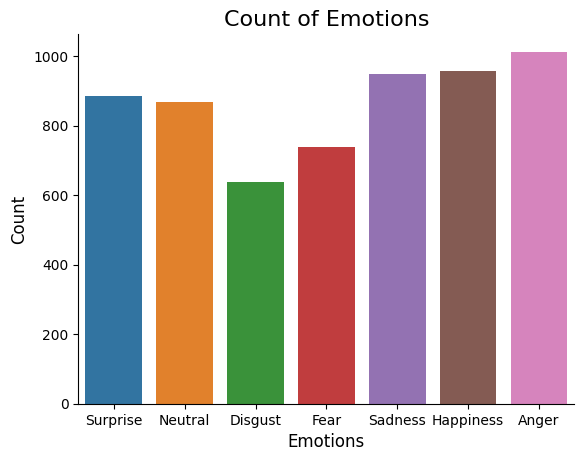

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.title('Count of Emotions', size=16)
sns.countplot(x=data_path.Emotions)
palette=('viridis')
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

# 3. ***MFCC***

In [41]:
data,sr = librosa.load(file_path[0])
sr
ipd.Audio(data,rate=sr)

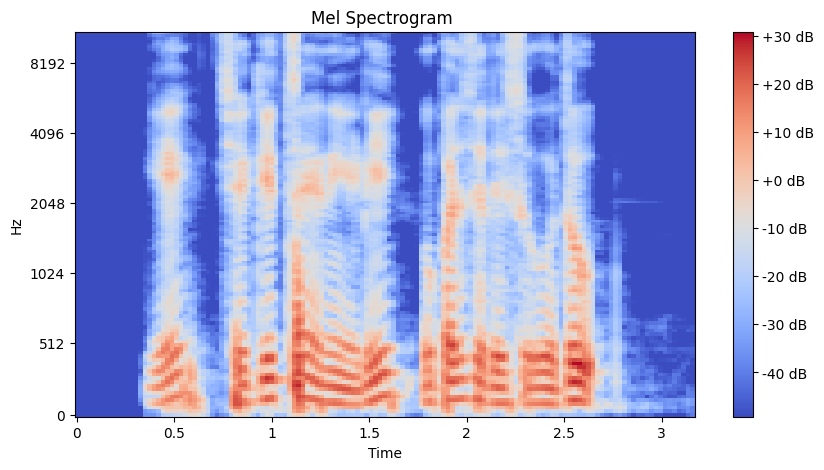

In [42]:
# CREATE LOG MEL SPECTROGRAM
plt.figure(figsize=(10, 5))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000)
log_spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(log_spectrogram, y_axis='mel', sr=sr, x_axis='time');
plt.title('Mel Spectrogram ')
plt.colorbar(format='%+2.0f dB')

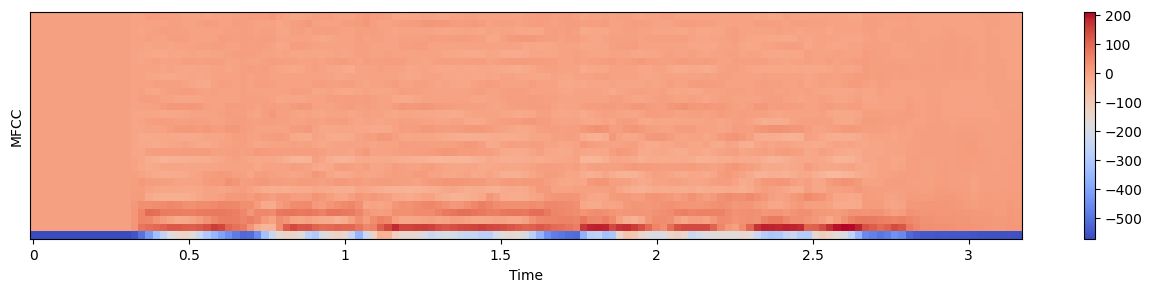

In [43]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=30)

# MFCC
plt.figure(figsize=(16, 10))
plt.subplot(3,1,1)
librosa.display.specshow(mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

ipd.Audio(data,rate=sr)

# 4.  ***DATA AUGMENTATION***

In [44]:
# NOISE
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

# STRETCH
def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate)
# SHIFT
def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)
# PITCH
def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sampling_rate, pitch_factor)

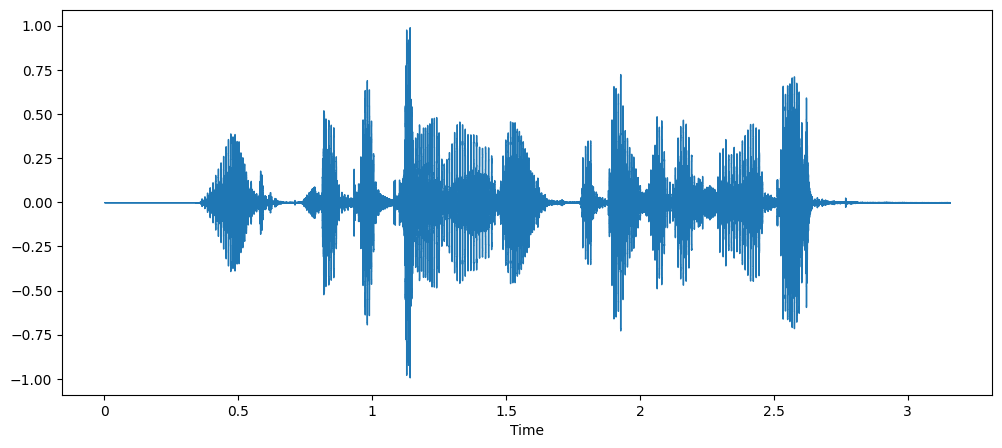

In [45]:
# NORMAL AUDIO
import librosa.display
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=data, sr=sr)
ipd.Audio(data,rate=sr)

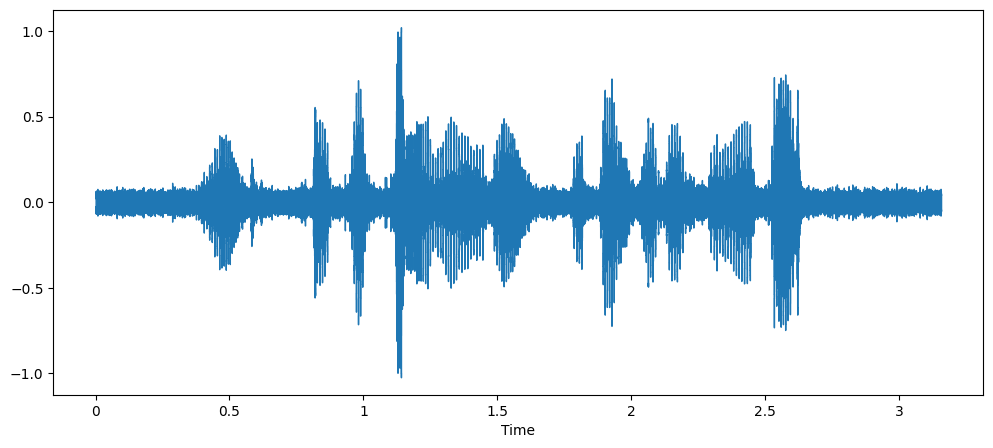

In [47]:
# AUDIO WITH NOISE
x = noise(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

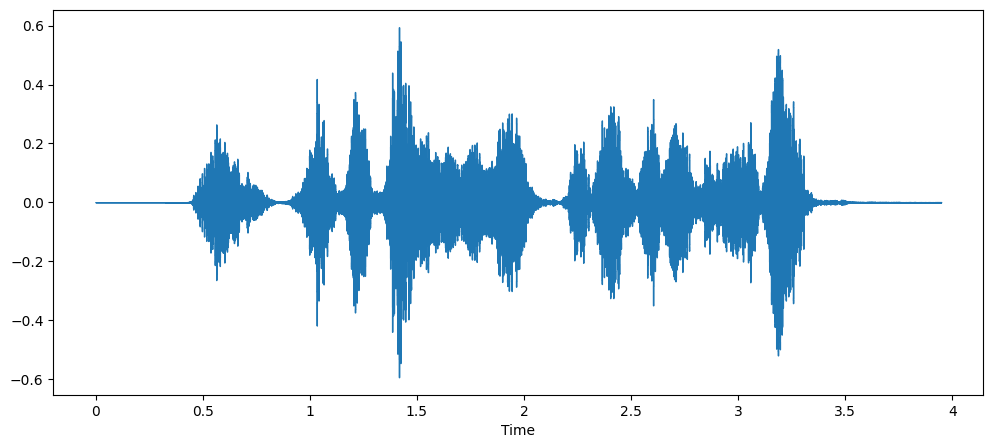

In [48]:
# STRETCH FUNCTION
def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate=rate)

x = stretch(data)  
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=x, sr=sr)  
ipd.Audio(x, rate=sr)

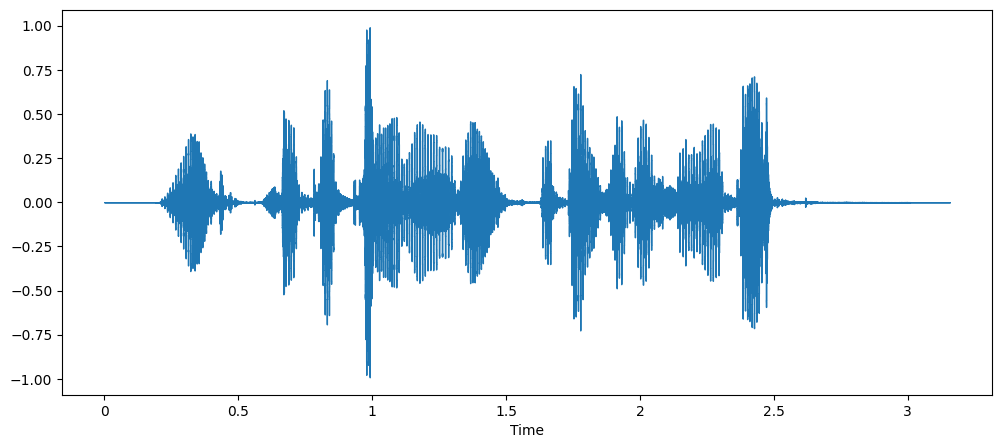

In [49]:
# SHIFTED AUDIO
x = shift(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

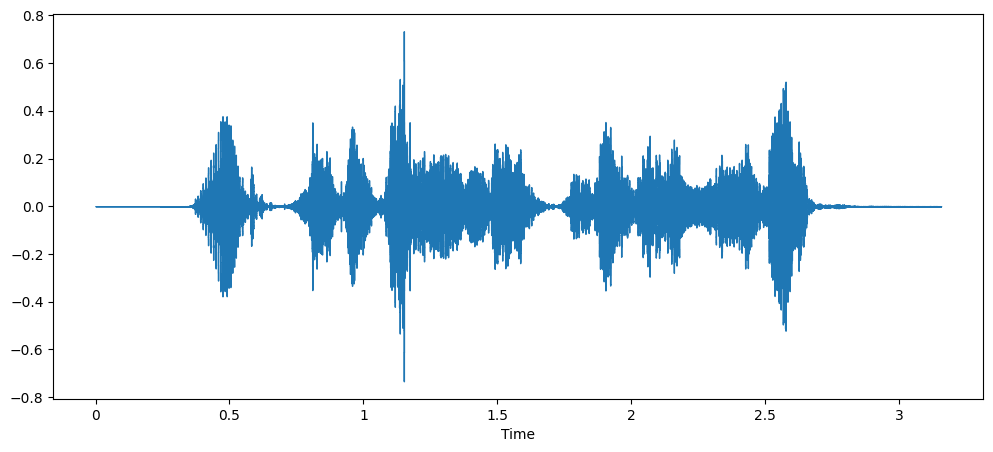

In [50]:
#AUDIO PITCH
def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

x = pitch(data, sr) 
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=x, sr=sr)  
ipd.Audio(x, rate=sr)  

# 5. ***VGGISH FEATURES***

In [51]:
def extractFeatures(audioFile):
    try:
        waveform, sr = librosa.load(audioFile)
        waveform, _ = librosa.effects.trim(waveform)
        features = vggish(waveform).numpy()
        return features, audioFile
    except Exception as e:
        print(f"Error processing {audioFile}: {e}")
        return None, None

In [52]:
data = []
for actor_folder in tqdm(os.listdir(ravdess), desc='Processing folders'):
    actor_path = os.path.join(ravdess, actor_folder)

    if os.path.isdir(actor_path):  
        for file in os.listdir(actor_path):
            filePath = os.path.join(actor_path, file)

            if file.endswith('.wav'):
                features, path = extractFeatures(filePath)  

                if features is not None:
                    emotion_index = file.split('-')[2]  
                    emotion_mapping = {
                        '01': 'Neutral',
                        '02': 'Boredom/Calm',
                        '03': 'Happiness',
                        '04': 'Sadness',
                        '05': 'Anger',
                        '06': 'Fear',
                        '07': 'Disgust',
                        '08': 'Surprise'
                    }

                    emotion = emotion_mapping.get(emotion_index, 'unknown') 
                    features = np.array(features)
                    data.append([features, emotion, path]) 

Processing folders: 100%|██████████| 25/25 [01:07<00:00,  2.68s/it]


In [53]:
ravdess_df = pd.DataFrame(data, columns=['Features', 'Emotions', 'Path'])

print(ravdess_df.head())
print("______________________________________________")
print(ravdess_df.tail())
print("_________________________________________")
print(ravdess_df.Emotions.value_counts())

                                            Features  Emotions  \
0  [[0.29071337, -0.23754919, 0.049498662, -0.274...  Surprise   
1  [[0.7098691, -0.29326525, -0.25508785, -0.8122...   Neutral   
2  [[0.770166, -0.20492303, -0.13505906, -0.61996...   Disgust   
3  [[-0.22096476, -0.24673536, 0.15931827, -0.015...   Disgust   
4  [[0.9586816, -0.35651866, -0.01613319, -0.5709...   Neutral   

                                                Path  
0  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...  
1  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...  
2  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...  
3  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...  
4  /kaggle/input/ravdess-dataset/RAV DESS/ravdess...  
______________________________________________
                                               Features Emotions  \
1435  [[-0.3708082, 0.10860671, 0.3097905, 0.2760945...     Fear   
1436  [[0.8639636, -0.40945342, -0.16613638, -0.8918...    Anger   
1437  [[-0.18470117, -

In [54]:
emotion_map = {
    'W': 'Anger',
    'L': 'Boredom/Calm',
    'E': 'Disgust',
    'A': 'Fear',
    'F': 'Happiness',
    'T': 'Sadness',
    'N': 'Neutral'
}

data = []

for file in tqdm(os.listdir(emodb), desc='Processing files'):
    filePath = os.path.join(emodb, file)
    features,path = extractFeatures(filePath)

    if features is not None:
        emotion_code = file[5]
        emotion = emotion_map.get(emotion_code, 'Unknown')  
        data.append([features, emotion, path])

Processing files: 100%|██████████| 535/535 [00:19<00:00, 27.05it/s]


In [55]:
emodb_df = pd.DataFrame(data, columns=['Features', 'Emotions', 'Path'])

print(emodb_df.head())
print("______________________________________________")
print(emodb_df.tail())
print("_________________________________________")
print(emodb_df.Emotions.value_counts())

                                            Features   Emotions  \
0  [[-0.011949867, -0.073373795, -0.2698515, -0.4...  Happiness   
1  [[0.3155643, -0.07918784, 0.04963769, -0.51746...  Happiness   
2  [[-0.17183772, 0.51639247, -0.053473294, -0.81...      Anger   
3  [[-0.21205714, 0.24747165, -0.09659168, -0.685...      Anger   
4  [[0.059953988, 0.37397605, 0.027395248, -0.558...      Anger   

                                             Path  
0  /kaggle/input/emodbdata/EMO DB/wav/15a04Fd.wav  
1  /kaggle/input/emodbdata/EMO DB/wav/13b02Fb.wav  
2  /kaggle/input/emodbdata/EMO DB/wav/09b01Wb.wav  
3  /kaggle/input/emodbdata/EMO DB/wav/15a01Wa.wav  
4  /kaggle/input/emodbdata/EMO DB/wav/14a05Wa.wav  
______________________________________________
                                              Features      Emotions  \
530  [[0.28636965, -0.15817252, 0.18323168, -0.9934...       Neutral   
531  [[-0.13224909, 0.09890658, -0.29572093, -0.478...  Boredom/Calm   
532  [[0.08555868, -0.

In [56]:
data = []

emotion_mapping = {
    'OAF_Fear': 'Fear',
    'OAF_Pleasant_surprise': 'Surprise',
    'OAF_Sad': 'Sadness',
    'OAF_angry': 'Anger',
    'OAF_disgust': 'Disgust',
    'OAF_happy': 'Happiness',
    'OAF_neutral': 'Neutral',
    'YAF_angry': 'Anger',
    'YAF_disgust': 'Disgust',
    'YAF_fear': 'Fear',
    'YAF_happy': 'Happiness',
    'YAF_neutral': 'Neutral',
    'YAF_pleasant_surprised': 'Surprise',
    'YAF_sad': 'Sadness'
}

for emotion_folder in tqdm(os.listdir(tess), desc='Processing folders'):
    emotion_path = os.path.join(tess, emotion_folder)

    if os.path.isdir(emotion_path): 
        for file in os.listdir(emotion_path):
            filePath = os.path.join(emotion_path, file)

            if file.endswith('.wav'):
                features, path = extractFeatures(filePath)

                if features is not None:
                    emotion = emotion_mapping.get(emotion_folder, 'unknown') 
                    data.append([features, emotion, path])


Processing folders: 100%|██████████| 15/15 [01:23<00:00,  5.54s/it]


In [57]:
tess_df = pd.DataFrame(data, columns=['Features', 'Emotions', 'Path'])

print(tess_df.head())
print("______________________________________________")
print(tess_df.tail())
print("_________________________________________")
print(tess_df.Emotions.value_counts())

                                            Features Emotions  \
0  [[-0.09902096, 0.030325651, 0.039350778, -0.96...     Fear   
1  [[0.038755655, -0.13567075, -0.050776333, -0.8...     Fear   
2  [[0.26397708, -0.07883367, -0.0071262717, -0.7...     Fear   
3  [[0.11832471, -0.20351014, -0.09470293, -0.539...     Fear   
4  [[0.12989417, -0.14018297, 0.19770679, -0.6447...     Fear   

                                                Path  
0  /kaggle/input/tess-dataset/TESS/TESS Toronto e...  
1  /kaggle/input/tess-dataset/TESS/TESS Toronto e...  
2  /kaggle/input/tess-dataset/TESS/TESS Toronto e...  
3  /kaggle/input/tess-dataset/TESS/TESS Toronto e...  
4  /kaggle/input/tess-dataset/TESS/TESS Toronto e...  
______________________________________________
                                               Features  Emotions  \
2795  [[-0.125848, 0.011508852, 0.17966275, -0.55567...  Surprise   
2796  [[-0.22873959, -0.035745025, 0.24312428, -0.74...  Surprise   
2797  [[-0.1951764, 0.049

In [58]:
emotion_map = {
    'angry': 'Anger',
    'surprised': 'Surprise',
    'happy': 'Happiness',
    'sad': 'Sadness',
    'natural': 'Neutral',
    'neutral': 'Neutral'
}

data = []

for emotion_folder in tqdm(os.listdir(bangla), desc='Processing folders'):
    emotion_path = os.path.join(bangla, emotion_folder)

    if os.path.isdir(emotion_path):  # Ensure it's a directory
        for file in os.listdir(emotion_path):
            filePath = os.path.join(emotion_path, file)

            if file.endswith('.wav'):
                features, path = extractFeatures(filePath)

                if features is not None:
                    emotion = emotion_map.get(emotion_folder.lower(), 'unknown')  
                    data.append([features, emotion, path])

Processing folders: 100%|██████████| 5/5 [00:51<00:00, 10.26s/it]


In [59]:
bangla_df = pd.DataFrame(data, columns=['Features', 'Emotions', 'Path'])

print(bangla_df.head())
print("______________________________________________")
print(bangla_df.tail())
print("_________________________________________")
print(bangla_df.Emotions.value_counts())

                                            Features Emotions  \
0  [[0.5586802, -0.25286207, -0.3017487, -0.92410...    Anger   
1  [[0.7911289, -0.31652662, 0.01168099, -0.90390...    Anger   
2  [[-0.28401706, -0.10793677, 0.09138116, -0.458...    Anger   
3  [[0.23719646, -0.24559703, 0.2603096, -0.37019...    Anger   
4  [[-0.04999715, 0.059994772, 0.043727458, 0.146...    Anger   

                                                Path  
0  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...  
1  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...  
2  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...  
3  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...  
4  /kaggle/input/bangla/bangla/Angry/03-01-03-02-...  
______________________________________________
                                               Features Emotions  \
1075  [[0.43323138, -0.22457236, 0.05776985, -0.6698...  Neutral   
1076  [[0.07960844, -0.2430841, 0.25166893, -0.13401...  Neutral   
1077  [[0.21192543, -0.30451

In [60]:
data = []

emotion_mapping = {
    '1': 'Anger',
    '2': 'Sadness',
    '3': 'Surprise',
    '4': 'Happiness',
    '5': 'Fear',
    '6': 'Neutral'
}
for file in tqdm(os.listdir(kannada), desc='Processing files'):
    filePath = os.path.join(kannada, file)

    if file.endswith('.wav'):
        features, path = extractFeatures(filePath)

        if features is not None:
            emotion_code = file[4]  
            emotion = emotion_mapping.get(emotion_code, 'unknown')  
            data.append([features, emotion, path])

Processing files: 100%|██████████| 468/468 [00:21<00:00, 21.43it/s]


In [61]:
kannada_df = pd.DataFrame(data, columns=['Features', 'Emotions', 'Path'])

print(kannada_df.head())
print("______________________________________________")
print(kannada_df.tail())
print("_________________________________________")
print(kannada_df.Emotions.value_counts())

                                            Features   Emotions  \
0  [[-0.07228947, -0.15022045, -0.14010519, -0.00...    Neutral   
1  [[-0.21047863, 0.30308443, 0.21780367, -0.7336...    Neutral   
2  [[-0.27234337, 0.32667843, 0.03385195, -0.6482...  Happiness   
3  [[-0.03487882, 0.105618045, 0.41841578, -0.123...      Anger   
4  [[0.04202673, -0.12224305, 0.032100916, -0.268...       Fear   

                                                Path  
0  /kaggle/input/kannada/kannada/kannada/12-06-01...  
1  /kaggle/input/kannada/kannada/kannada/13-06-02...  
2  /kaggle/input/kannada/kannada/kannada/13-04-02...  
3  /kaggle/input/kannada/kannada/kannada/07-01-02...  
4  /kaggle/input/kannada/kannada/kannada/12-05-04...  
______________________________________________
                                              Features   Emotions  \
463  [[0.22941774, -0.20018849, 0.17775428, -0.4764...    Neutral   
464  [[0.67325425, -0.08639377, 0.1983295, -0.61435...    Neutral   
465  [[0.3887

In [62]:
combvgg = pd.concat([ravdess_df, emodb_df, tess_df, bangla_df, kannada_df], axis = 0)
combvgg.to_csv("combvgg.csv",index=False)
combvgg.head()

,Features,Emotions,Path
0,"[[0.29071337, -0.23754919, 0.049498662, -0.274...",Surprise,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...
1,"[[0.7098691, -0.29326525, -0.25508785, -0.8122...",Neutral,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...
2,"[[0.770166, -0.20492303, -0.13505906, -0.61996...",Disgust,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...
3,"[[-0.22096476, -0.24673536, 0.15931827, -0.015...",Disgust,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...
4,"[[0.9586816, -0.35651866, -0.01613319, -0.5709...",Neutral,/kaggle/input/ravdess-dataset/RAV DESS/ravdess...


In [63]:
combvgg = combvgg[combvgg['Emotions'] != 'Boredom/Calm']
print(combvgg['Emotions'].value_counts())

Emotions
Anger        1013
Happiness     957
Sadness       948
Surprise      886
Neutral       869
Fear          739
Disgust       638
Name: count, dtype: int64


In [65]:
x = combvgg['Features'].tolist()
feature_shapes = [features.shape for features in x]
#print("Feature shapes:", feature_shapes)

In [66]:
import numpy as np

target_shape = (5, 128)
padded_features = []

for features in combvgg['Features']:
    if features is not None:
        current_shape = features.shape

        padded_feature = np.zeros(target_shape)

        if current_shape[0] < target_shape[0]:
            padded_feature[:current_shape[0], :current_shape[1]] = features
        else:
            padded_feature = features[:target_shape[0], :target_shape[1]]

        padded_features.append(padded_feature)

x = np.array(padded_features)
y = combvgg['Emotions'].values

# 6. ***FEATURE EXTRACTION***

In [67]:
import numpy as np
import pandas as pd
import librosa

combvgg = pd.read_csv('combvgg.csv')  

def zcr(data, frame_length, hop_length):
    zcr = librosa.feature.zero_crossing_rate(data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(zcr)

def rmse(data, frame_length=2048, hop_length=512):
    rmse = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(rmse)

def mfccs(data, sr, frame_length=2048, hop_length=512, flatten: bool = True):
    mfccs = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=13, hop_length=hop_length)
    return np.squeeze(mfccs.T) if not flatten else np.ravel(mfccs.T)

def extract_features(data, sr=22050, frame_length=2048, hop_length=512):
    result = np.array([])

    result = np.hstack((
        result,
        zcr(data, frame_length, hop_length),
        rmse(data, frame_length, hop_length),
        mfccs(data, sr, frame_length, hop_length)
    ))
    return result

def get_combvgg_features(file_path):
    matching_row = combvgg[combvgg['Path'] == file_path]
    
    if not matching_row.empty:
        return matching_row['Features'].values[0]  
    else:
        return np.array([]) 
def get_features(path, duration=2.5, offset=0.6):
    data, sr = librosa.load(path, duration=duration, offset=offset)
    audio = extract_features(data)

    combvgg_features = get_combvgg_features(path)
    
    if isinstance(combvgg_features, (list, np.ndarray)):  # Ensure the features are in a valid format
        audio = np.hstack((audio, combvgg_features))

    noised_audio = noise(data)
    aud2 = extract_features(noised_audio)

    combvgg_features = get_combvgg_features(path)
    if isinstance(combvgg_features, (list, np.ndarray)):
        aud2 = np.hstack((aud2, combvgg_features))
    audio = np.vstack((audio, aud2))

    pitched_noised_audio = pitch(noised_audio, sr)
    aud3 = extract_features(pitched_noised_audio)

    combvgg_features = get_combvgg_features(path)
    if isinstance(combvgg_features, (list, np.ndarray)):
        aud3 = np.hstack((aud3, combvgg_features))
    audio = np.vstack((audio, aud3))

    return audio

In [68]:
import multiprocessing as mp
print("Number of processors: ", mp.cpu_count())

Number of processors:  4


In [69]:
print("Unique values in Emotions column before processing:", np.unique(data_path.Emotions))
data_path = data_path[~data_path['Emotions'].isin(['Boredom/Calm'])]

Unique values in Emotions column before processing: ['Anger' 'Disgust' 'Fear' 'Happiness' 'Neutral' 'Sadness' 'Surprise']


In [70]:
import timeit
from tqdm import tqdm
start = timeit.default_timer()
X, Y = [], []

for path, emotion, index in tqdm(zip(data_path.Path, data_path.Emotions, range(data_path.Path.shape[0]))):
    features = get_features(path)  
    if index % 500 == 0:
        print(f'{index} audio has been processed')
    
    for i in features:
        X.append(i)
        Y.append(emotion)

print('Done')
stop = timeit.default_timer()
print('Time: ', stop - start)

2it [00:00,  2.51it/s]

0 audio has been processed


502it [01:26,  6.10it/s]

500 audio has been processed


1002it [02:52,  5.72it/s]

...

5500 audio has been processed


6002it [14:03,  6.13it/s]

6000 audio has been processed


6050it [14:10,  7.11it/s]

Done
Time:  850.7212490919999


In [71]:
len(X), len(Y), data_path.Path.shape
print(data_path.columns)

Index(['Emotions', 'Path'], dtype='object')


In [72]:
Emotions = pd.DataFrame(X)
Emotions['Emotions'] = Y
Emotions.to_csv('emotion.csv', index=False)
Emotions.head()

,0,1,2,3,4,5,6,7,8,9,...,1611,1612,1613,1614,1615,1616,1617,1618,1619,Emotions
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,9.226068,7.151143,5.051465,3.085226,1.378609,0.018685,-0.948768,-1.517690,-1.716483,Surprise
1,0.250977,0.373047,0.487793,0.483887,0.467773,0.473145,0.468750,0.462402,0.480957,0.479004,...,5.452994,0.382324,1.909619,0.853043,-0.881080,2.288671,-4.781040,1.384848,4.433243,Surprise
2,0.248047,0.366699,0.481934,0.473633,0.464355,0.454590,0.458984,0.451172,0.454590,0.466797,...,1.838589,-2.644772,-7.135615,3.411676,-3.018317,2.118037,-2.028229,7.616231,6.759736,Surprise
3,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,7.018431,4.313147,2.402373,1.351023,1.071207,1.380421,2.005284,2.586417,2.746852,Neutral
4,0.252441,0.377441,0.499512,0.490723,0.489746,0.489258,0.488770,0.492676,0.496094,0.500488,...,-0.499873,-0.100633,-2.236813,1.563683,-0.151016,-2.860116,2.726603,-0.488366,1.028616,Neutral


In [73]:
len(X), len(Y), data_path.Path.shape
Emotions = pd.read_csv('./emotion.csv')
Emotions.head()

,0,1,2,3,4,5,6,7,8,9,...,1611,1612,1613,1614,1615,1616,1617,1618,1619,Emotions
0,0.343750,0.479492,0.573730,0.458008,0.375488,0.301758,0.269043,0.255371,0.251465,0.251953,...,9.226068,7.151143,5.051465,3.085226,1.378609,0.018685,-0.948768,-1.517690,-1.716483,Surprise
1,0.250977,0.373047,0.487793,0.483887,0.467773,0.473145,0.468750,0.462402,0.480957,0.479004,...,5.452994,0.382324,1.909619,0.853043,-0.881080,2.288671,-4.781040,1.384848,4.433243,Surprise
2,0.248047,0.366699,0.481934,0.473633,0.464355,0.454590,0.458984,0.451172,0.454590,0.466797,...,1.838589,-2.644772,-7.135615,3.411676,-3.018317,2.118037,-2.028229,7.616231,6.759736,Surprise
3,0.437500,0.659668,0.862305,0.878906,0.865234,0.847168,0.845703,0.827637,0.835938,0.667969,...,7.018431,4.313147,2.402373,1.351023,1.071207,1.380421,2.005284,2.586417,2.746852,Neutral
4,0.252441,0.377441,0.499512,0.490723,0.489746,0.489258,0.488770,0.492676,0.496094,0.500488,...,-0.499873,-0.100633,-2.236813,1.563683,-0.151016,-2.860116,2.726603,-0.488366,1.028616,Neutral


In [74]:
print(Emotions.isna().any())

0           False
1           False
2           False
3           False
4           False
            ...  
1616         True
1617         True
1618         True
1619         True
Emotions    False
Length: 1621, dtype: bool


In [75]:
Emotions=Emotions.fillna(0)
print(Emotions.isna().any())
Emotions.shape

0           False
1           False
2           False
3           False
4           False
            ...  
1616        False
1617        False
1618        False
1619        False
Emotions    False
Length: 1621, dtype: bool


(18150, 1621)

In [76]:
np.sum(Emotions.isna())

0           0
1           0
2           0
3           0
4           0
           ..
1616        0
1617        0
1618        0
1619        0
Emotions    0
Length: 1621, dtype: int64

# 7. ***DATA PREPARATION***

In [77]:
X = Emotions.iloc[: ,:-1].values
Y = Emotions['Emotions'].values
len(X), len(Y), data_path.Path.shape
print("First 10 values of Y:", Y[:10])

First 10 values of Y: ['Surprise' 'Surprise' 'Surprise' 'Neutral' 'Neutral' 'Neutral' 'Disgust'
 'Disgust' 'Disgust' 'Disgust']


In [78]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

Y = np.array(Y)

print("Y contents:", Y)
print("Y shape:", Y.shape)

encoder = OneHotEncoder()

Y_encoded = encoder.fit_transform(Y.reshape(-1, 1)).toarray()

print("Encoded Y shape:", Y_encoded.shape)

Y contents: ['Surprise' 'Surprise' 'Surprise' ... 'Happiness' 'Happiness' 'Happiness']
Y shape: (18150,)
Encoded Y shape: (18150, 7)


In [79]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y_encoded, random_state=42,test_size=0.2, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape
print(np.unique(Y))

['Anger' 'Disgust' 'Fear' 'Happiness' 'Neutral' 'Sadness' 'Surprise']


In [80]:
X_train = x_train.reshape(x_train.shape[0] , x_train.shape[1] , 1)
X_test = x_test.reshape(x_test.shape[0] , x_test.shape[1] , 1)

In [81]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((14520, 1620), (14520, 7), (3630, 1620), (3630, 7))

In [82]:
import keras
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.layers import LSTM,BatchNormalization , GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD

In [83]:
from keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
model_checkpoint = ModelCheckpoint('best_model1_weights.keras', monitor='val_accuracy', save_best_only=True)

In [84]:
early_stop=EarlyStopping(monitor='val_acc',mode='auto',patience=5,restore_best_weights=True)
lr_reduction=ReduceLROnPlateau(monitor='val_acc',patience=3,verbose=1,factor=0.5,min_lr=0.00001)

# 8. ***LSTM MODEL***

In [86]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional, BatchNormalization, GRU
from keras.optimizers import RMSprop, Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from collections.abc import Iterable

def build_model(input_shape):
    model01 = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(1620, 1)),  
    MaxPooling1D(pool_size=2),  
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=True),  
    Bidirectional(LSTM(32, return_sequences=True)), 
    Dropout(0.3),
    LSTM(32),  
    Dense(7, activation='softmax')  
])
    return model01

input_shape = (1620, 1)
model01 = build_model(input_shape)

initial_learning_rate = 1e-4
optimizer = Adam(learning_rate=initial_learning_rate)

model01.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
model01.summary()
print(Iterable)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 1618, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 809, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 809, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 809, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 809, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 809, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 809, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,719 (373.90 KB)

 Trainable params: 95,719 (373.90 KB)

 Non-trainable params: 0 (0.00 B)

<class 'collections.abc.Iterable'>


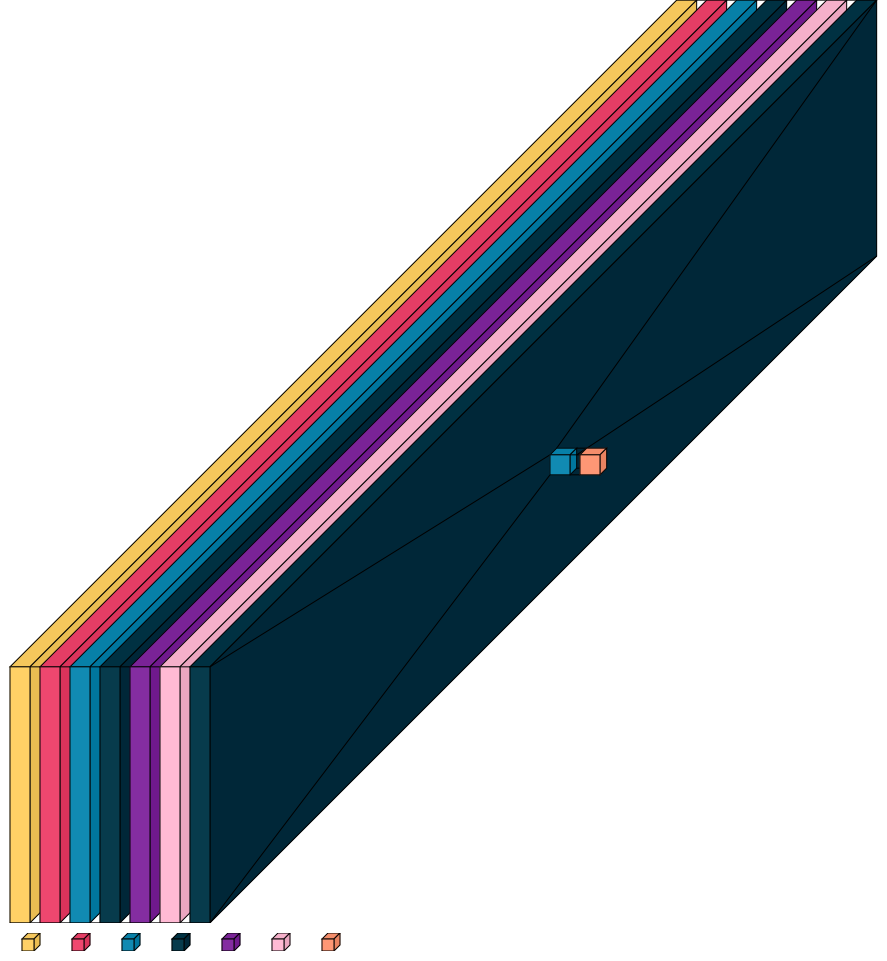

In [87]:
import visualkeras
visualkeras.layered_view(model01, legend=True)

In [88]:
print(X_train.shape)
print(y_train.shape)
X_train = X_train.astype('float32')

print(y_train[0])

(14520, 1620, 1)
(14520, 7)
[0. 1. 0. 0. 0. 0. 0.]


In [89]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [90]:
from keras.callbacks import ModelCheckpoint
from keras.callbacks import LearningRateScheduler
import tensorflow as tf


def scheduler(epoch, lr):
    if 60 < epoch < 100:
        return float(lr * tf.math.exp(-0.1))
    return lr


lr_scheduler_callback = LearningRateScheduler(scheduler)

checkpoint_filepath = 'best_model6.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1)

hist = model01.fit(X_train, y_train, validation_data = (X_test, y_test), 
                   epochs=120, batch_size=64, callbacks=[model_checkpoint_callback, lr_scheduler_callback])

Epoch 1/120
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.1692 - loss: 1.9239
Epoch 1: val_accuracy improved from -inf to 0.19559, saving model to best_model6.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 46s 179ms/step - accuracy: 0.1693 - loss: 1.9239 - val_accuracy: 0.1956 - val_loss: 1.9105 - learning_rate: 0.0010
Epoch 2/120
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.1844 - loss: 1.9066
Epoch 2: val_accuracy did not improve from 0.19559
227/227 ━━━━━━━━━━━━━━━━━━━━ 40s 177ms/step - accuracy: 0.1844 - loss: 1.9066 - val_accuracy: 0.1939 - val_loss: 1.9117 - learning_rate: 0.0010
Epoch 3/120
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.1846 - loss: 1.9035
Epoch 3: val_accuracy improved from 0.19559 to 0.21433, saving model to best_model6.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 40s 177ms/step - accuracy: 0.1846 - loss: 1.9034 - val_accuracy: 0.2143 - val_loss: 1.8927 - learning_rate: 0.0010
Epoch 4/120
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.2055

# 8. ***METRICS***

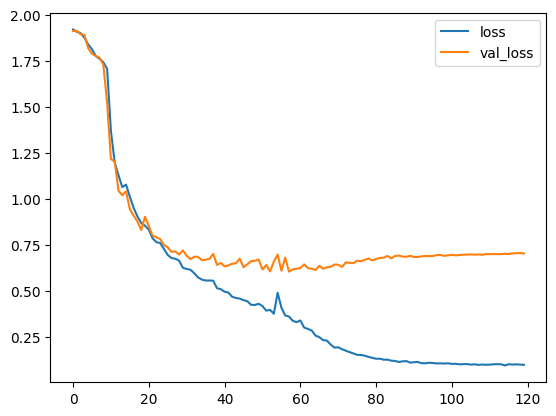

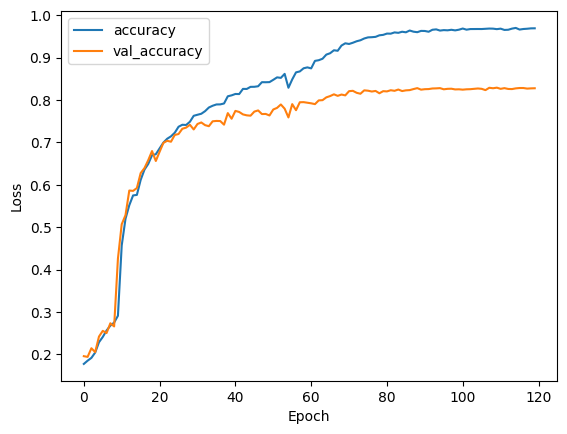

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

historyDf = pd.DataFrame(hist.history)

historyDf[['loss', 'val_loss']].plot()
historyDf[['accuracy', 'val_accuracy']].plot()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [92]:
print("Model Accuracy: " , model01.evaluate(X_test,y_test)[1]*100 , "%")

114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.8209 - loss: 0.7446
Model Accuracy:  82.78236985206604 %


In [93]:
X_test = X_test.astype('float32')
y_pred = model01.predict(X_test) 
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step


In [94]:
class_report = classification_report(y_test_classes, y_pred_classes)
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       634
           1       0.88      0.90      0.89       376
           2       0.83      0.82      0.82       444
           3       0.77      0.77      0.77       582
           4       0.82      0.85      0.83       544
           5       0.81      0.80      0.81       564
           6       0.81      0.82      0.81       486

    accuracy                           0.83      3630
   macro avg       0.83      0.83      0.83      3630
weighted avg       0.83      0.83      0.83      3630



114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step


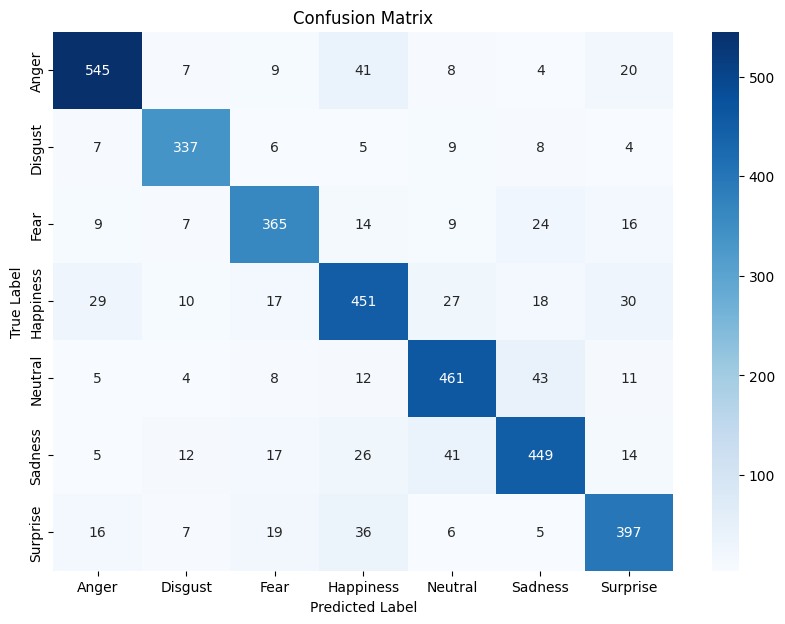

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

class_names = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

def plot_confusion_matrix(model01, X_test, y_test, class_names):
    y_pred = model01.predict(X_test)
    if y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
    y_test_labels = np.argmax(y_test, axis=1) if y_test.shape[1] > 1 else y_test
    
    cm1 = confusion_matrix(y_test_labels, y_pred)
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    return cm1

cm1 = plot_confusion_matrix(model01, X_test, y_test, class_names)

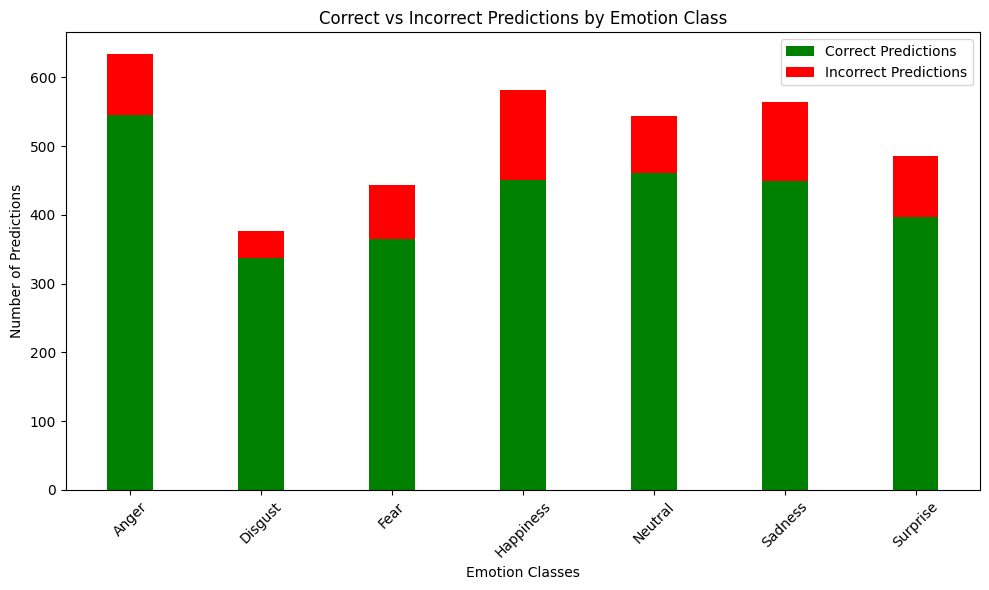

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class_names = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

total_files = np.sum(cm1, axis=1)

correct_predictions = np.diag(cm1)

incorrect_predictions = total_files - correct_predictions

index = np.arange(len(class_names))
bar_width = 0.35  

plt.figure(figsize=(10, 6))
plt.bar(index, correct_predictions, bar_width, label='Correct Predictions', color='green')
plt.bar(index, incorrect_predictions, bar_width, bottom=correct_predictions, label='Incorrect Predictions', color='red')

plt.xlabel('Emotion Classes')
plt.ylabel('Number of Predictions')
plt.title('Correct vs Incorrect Predictions by Emotion Class')
plt.xticks(index, class_names, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [204]:
model01.save("lstm4.keras")

# 9. ***BASELINE MODEL***

Baseline accuracy (majority class): 17.47%
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.8209 - loss: 0.7446
Model accuracy: 82.78%
Your model is performing better than the baseline model.


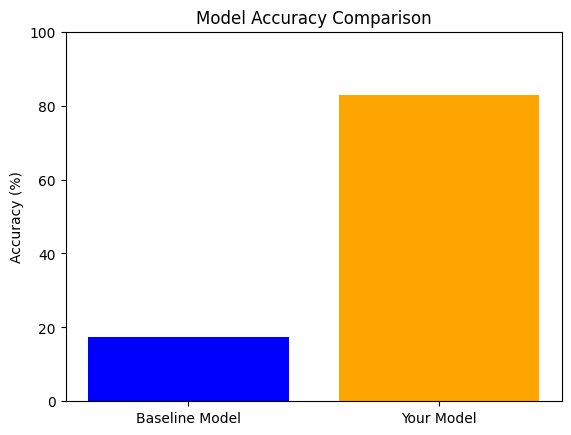

In [97]:
from sklearn.metrics import accuracy_score
majority_class = y_train.argmax(axis=1)  
majority_class_value = np.bincount(majority_class).argmax()

baseline_predictions = np.full(y_test.shape[0], majority_class_value)

baseline_accuracy = accuracy_score(y_test.argmax(axis=1), baseline_predictions)
print(f'Baseline accuracy (majority class): {baseline_accuracy * 100:.2f}%')

score = model01.evaluate(X_test,y_test)[1]*100
model_accuracy = score 
print(f'Model accuracy: {model_accuracy:.2f}%')

if model_accuracy > baseline_accuracy * 100:
    print("Your model is performing better than the baseline model.")
else:
    print("Your model is not performing better than the baseline model.")


accuracies = [baseline_accuracy * 100, model_accuracy]
labels = ['Baseline Model', 'Your Model']

plt.bar(labels, accuracies, color=['blue', 'orange'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
plt.show()

# ***CNN***

# 1. DLIBRARIES

In [98]:
import pandas as pd
import numpy as np

import os
import sys
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import IPython.display as ipd
from IPython.display import Audio
import keras
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.layers import LSTM,BatchNormalization , GRU
from tensorflow.keras.layers import Dense, Embedding, LSTM, BatchNormalization, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
import tensorflow as tf

from tqdm import tqdm

from visualkeras import layered_view

import tensorflow_hub as hub
from tensorflow import keras
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras import layers, Sequential
from keras.callbacks import EarlyStopping
from warnings import filterwarnings
filterwarnings('ignore')

vggish = hub.load('https://tfhub.dev/google/vggish/1')

In [99]:
import numpy as np
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# 2. DATASETS

In [100]:
ravdess = "/kaggle/input/ravdess-dataset/RAV DESS/ravdess"
ravdess_directory_list = os.listdir(ravdess)
print(ravdess_directory_list)

['Actor_02', 'Actor_17', 'Actor_05', 'Actor_16', 'Actor_21', 'Actor_01', 'Actor_11', 'Actor_20', 'Actor_08', 'Actor_15', 'Actor_06', 'Actor_12', 'Actor_23', 'Actor_24', 'Actor_22', 'Actor_04', 'Actor_19', 'Actor_10', 'Actor_09', 'audio_speech_actors_01-24', 'Actor_14', 'Actor_03', 'Actor_13', 'Actor_18', 'Actor_07']


In [101]:
emodb = "/kaggle/input/emodbdata/EMO DB/wav"
tess = "/kaggle/input/tess-dataset/TESS/TESS Toronto emotional speech set data"
bangla = "/kaggle/input/bangla/bangla"
kannada = "/kaggle/input/kannada/kannada/kannada"

> 1. RAVDESS

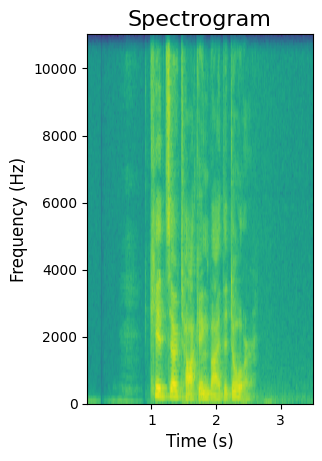

In [102]:
audioFile = '/kaggle/input/ravdess-dataset/RAV DESS/ravdess/Actor_03/03-01-01-01-01-02-03.wav'

waveform, sampleRate = librosa.load(audioFile)

plt.subplot(1, 2, 2)
plt.specgram(waveform, Fs = sampleRate)
plt.title('Spectrogram', fontsize = 16)
plt.xlabel('Time (s)', fontsize = 12)
plt.ylabel('Frequency (Hz)', fontsize = 12)

plt.show()

In [103]:
def extractFeatures(audioFile):
    try:
        waveform, sr = librosa.load(audioFile)

        waveform, _ = librosa.effects.trim(waveform)

        features = vggish(waveform).numpy()
        return features
    except Exception as e:
        print(f"Error processing {audioFile}: {e}")
        return None

In [104]:
data = []
for actor_folder in tqdm(os.listdir(ravdess), desc='Processing folders'):
    actor_path = os.path.join(ravdess, actor_folder)

    if os.path.isdir(actor_path):  
        for file in os.listdir(actor_path):
            filePath = os.path.join(actor_path, file)

            if file.endswith('.wav'):
                features = extractFeatures(filePath)

                if features is not None:
                    emotion_index = file.split('-')[2]  
                    emotion_mapping = {
                        '01': 'Neutral',
                        '02': 'Boredom/Calm',
                        '03': 'Happiness',
                        '04': 'Sadness',
                        '05': 'Anger',
                        '06': 'Fear',
                        '07': 'Disgust',
                        '08': 'Surprise'
                    }

                    emotion = emotion_mapping.get(emotion_index, 'unknown')  # Default to 'unknown' if not found
                    data.append([features, emotion])

Processing folders: 100%|██████████| 25/25 [00:44<00:00,  1.77s/it]


In [105]:
ravdess_df = pd.DataFrame(data, columns=['Features', 'Emotions'])

print(ravdess_df.head())
print("______________________________________________")
print(ravdess_df.tail())
print("_________________________________________")
print(ravdess_df.Emotions.value_counts())

                                            Features  Emotions
0  [[0.29071337, -0.23754919, 0.049498662, -0.274...  Surprise
1  [[0.7098691, -0.29326525, -0.25508785, -0.8122...   Neutral
2  [[0.770166, -0.20492303, -0.13505906, -0.61996...   Disgust
3  [[-0.22096476, -0.24673536, 0.15931827, -0.015...   Disgust
4  [[0.9586816, -0.35651866, -0.01613319, -0.5709...   Neutral
______________________________________________
                                               Features Emotions
1435  [[-0.3708082, 0.10860671, 0.3097905, 0.2760945...     Fear
1436  [[0.8639636, -0.40945342, -0.16613638, -0.8918...    Anger
1437  [[-0.18470117, -0.21975306, 0.51456875, -0.194...  Sadness
1438  [[0.07892114, -0.31316617, -0.17944777, -0.089...  Disgust
1439  [[-0.09225765, -0.08155674, 0.12533657, 0.0784...    Anger
_________________________________________
Emotions
Surprise        192
Disgust         192
Fear            192
Sadness         192
Happiness       192
Boredom/Calm    192
Anger         

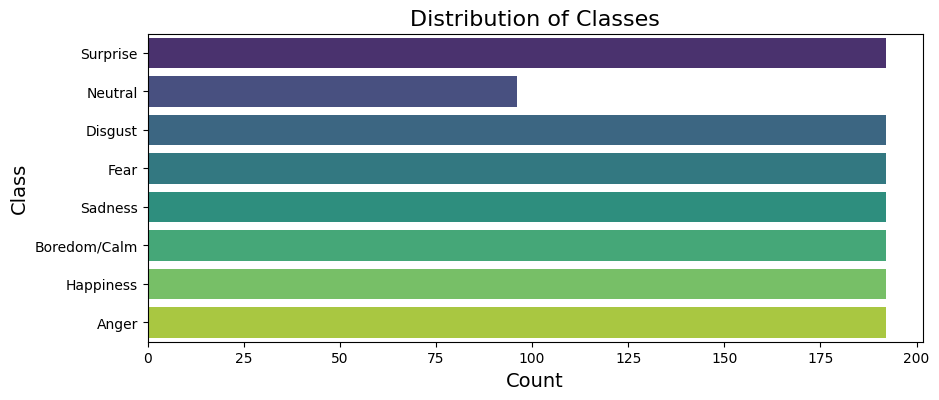

In [106]:
data = pd.DataFrame(data, columns=['Features', 'Class'])
data.head()

plt.figure(figsize=(10, 4))
sns.countplot(y=data['Class'], palette='viridis')
plt.title('Distribution of Classes', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Class', fontsize=14)
plt.show()

> 2. EMO-DB 

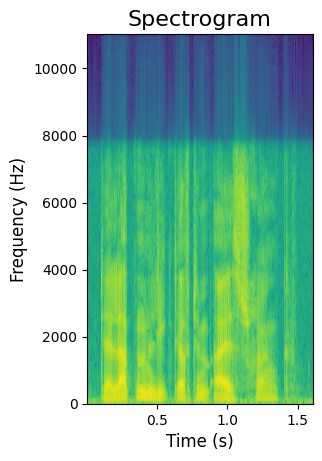

In [107]:
audioFile = '/kaggle/input/emodbdata/EMO DB/wav/03a01Nc.wav'

waveform, sampleRate = librosa.load(audioFile)

plt.subplot(1, 2, 2)
plt.specgram(waveform, Fs = sampleRate)
plt.title('Spectrogram', fontsize = 16)
plt.xlabel('Time (s)', fontsize = 12)
plt.ylabel('Frequency (Hz)', fontsize = 12)

plt.show()

In [108]:
emotion_map = {
    'W': 'Anger',
    'L': 'Boredom/Calm',
    'E': 'Disgust',
    'A': 'Fear',
    'F': 'Happiness',
    'T': 'Sadness',
    'N': 'Neutral'
}

data = []

for file in tqdm(os.listdir(emodb), desc='Processing files'):
    filePath = os.path.join(emodb, file)
    features = extractFeatures(filePath)

    if features is not None:
        emotion_code = file[5]
        emotion = emotion_map.get(emotion_code, 'Unknown')  
        data.append([features, emotion])

Processing files: 100%|██████████| 535/535 [00:13<00:00, 39.22it/s]


In [109]:
emodb_df = pd.DataFrame(data, columns=['Features', 'Emotions'])

print(emodb_df.head())
print("______________________________________________")
print(emodb_df.tail())
print("_________________________________________")
print(emodb_df.Emotions.value_counts())

                                            Features   Emotions
0  [[-0.011949867, -0.073373795, -0.2698515, -0.4...  Happiness
1  [[0.3155643, -0.07918784, 0.04963769, -0.51746...  Happiness
2  [[-0.17183772, 0.51639247, -0.053473294, -0.81...      Anger
3  [[-0.21205714, 0.24747165, -0.09659168, -0.685...      Anger
4  [[0.059953988, 0.37397605, 0.027395248, -0.558...      Anger
______________________________________________
                                              Features      Emotions
530  [[0.28636965, -0.15817252, 0.18323168, -0.9934...       Neutral
531  [[-0.13224909, 0.09890658, -0.29572093, -0.478...  Boredom/Calm
532  [[0.08555868, -0.30968043, 0.05647652, -0.6792...       Sadness
533  [[0.013903946, -0.27720407, -0.1448138, -0.223...       Neutral
534  [[-0.41406354, 0.15799502, 0.072046, -0.316534...     Happiness
_________________________________________
Emotions
Anger           127
Boredom/Calm     81
Neutral          79
Happiness        71
Fear             69
Sadn

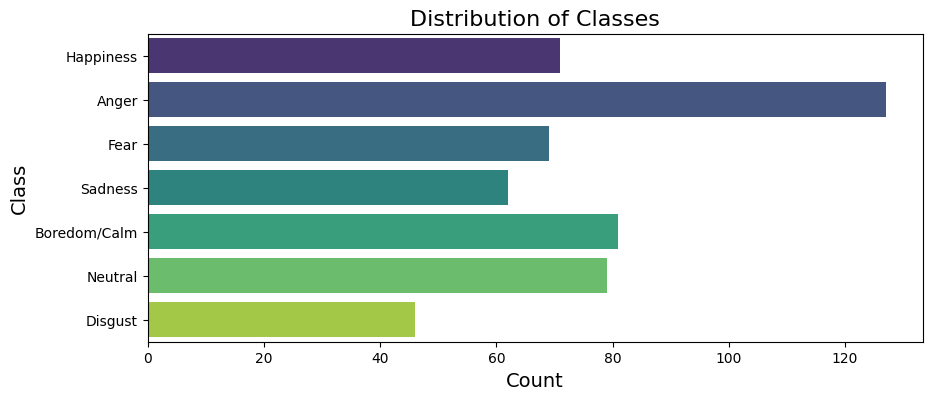

In [110]:
data = pd.DataFrame(data, columns=['Features', 'Class'])
data.head()

plt.figure(figsize=(10, 4))
sns.countplot(y=data['Class'], palette='viridis')
plt.title('Distribution of Classes', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Class', fontsize=14)
plt.show()

> 3. TESS

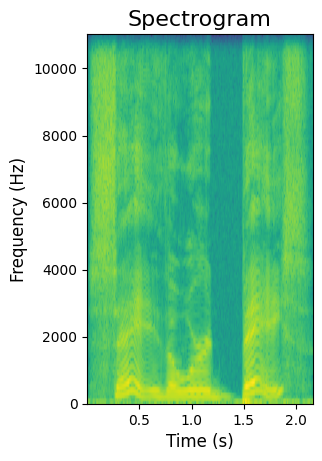

In [111]:
audioFile = '/kaggle/input/tess-dataset/TESS/TESS Toronto emotional speech set data/OAF_Pleasant_surprise/OAF_base_ps.wav'

waveform, sampleRate = librosa.load(audioFile)

plt.subplot(1, 2, 2)
plt.specgram(waveform, Fs = sampleRate)
plt.title('Spectrogram', fontsize = 16)
plt.xlabel('Time (s)', fontsize = 12)
plt.ylabel('Frequency (Hz)', fontsize = 12)

plt.show()

In [112]:
data = []

emotion_mapping = {
    'OAF_Fear': 'Fear',
    'OAF_Pleasant_surprise': 'Surprise',
    'OAF_Sad': 'Sadness',
    'OAF_angry': 'Anger',
    'OAF_disgust': 'Disgust',
    'OAF_happy': 'Happiness',
    'OAF_neutral': 'Neutral',
    'YAF_angry': 'Anger',
    'YAF_disgust': 'Disgust',
    'YAF_fear': 'Fear',
    'YAF_happy': 'Happiness',
    'YAF_neutral': 'Neutral',
    'YAF_pleasant_surprised': 'Surprise',
    'YAF_sad': 'Sadness'
}

for emotion_folder in tqdm(os.listdir(tess), desc='Processing folders'):
    emotion_path = os.path.join(tess, emotion_folder)

    if os.path.isdir(emotion_path):  # Ensure it's a directory
        for file in os.listdir(emotion_path):
            filePath = os.path.join(emotion_path, file)

            if file.endswith('.wav'):
                features = extractFeatures(filePath)

                if features is not None:
                    emotion = emotion_mapping.get(emotion_folder, 'unknown') 
                    data.append([features, emotion])


Processing folders: 100%|██████████| 15/15 [00:54<00:00,  3.63s/it]


In [113]:
tess_df = pd.DataFrame(data, columns=['Features', 'Emotions'])

print(tess_df.head())
print("______________________________________________")
print(tess_df.tail())
print("_________________________________________")
print(tess_df.Emotions.value_counts())

                                            Features Emotions
0  [[-0.09902096, 0.030325651, 0.039350778, -0.96...     Fear
1  [[0.038755655, -0.13567075, -0.050776333, -0.8...     Fear
2  [[0.26397708, -0.07883367, -0.0071262717, -0.7...     Fear
3  [[0.11832471, -0.20351014, -0.09470293, -0.539...     Fear
4  [[0.12989417, -0.14018297, 0.19770679, -0.6447...     Fear
______________________________________________
                                               Features  Emotions
2795  [[-0.125848, 0.011508852, 0.17966275, -0.55567...  Surprise
2796  [[-0.22873959, -0.035745025, 0.24312428, -0.74...  Surprise
2797  [[-0.1951764, 0.049127564, 0.0043948293, -0.37...  Surprise
2798  [[-0.14998382, -0.03592232, 0.18350239, -0.565...  Surprise
2799  [[-0.37033847, -0.16058862, 0.248813, -0.64660...  Surprise
_________________________________________
Emotions
Fear         400
Anger        400
Disgust      400
Neutral      400
Sadness      400
Surprise     400
Happiness    400
Name: count, dt

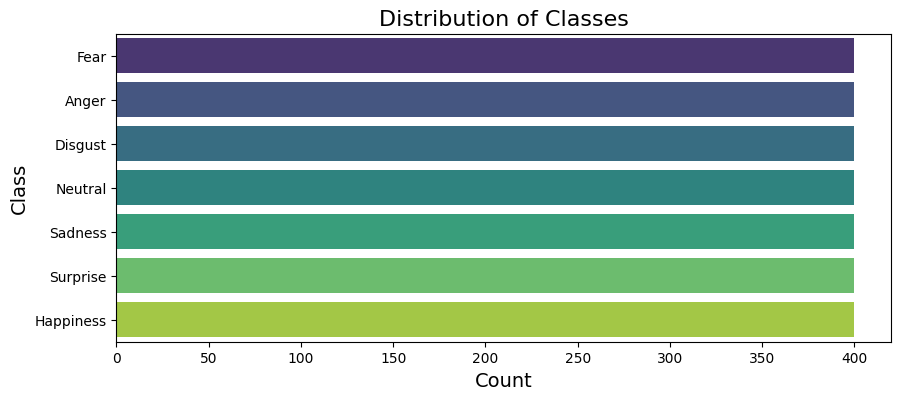

In [114]:
data = pd.DataFrame(data, columns=['Features', 'Class'])
data.head()

plt.figure(figsize=(10, 4))
sns.countplot(y=data['Class'], palette='viridis')
plt.title('Distribution of Classes', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Class', fontsize=14)
plt.show()

> 4. BANGLA

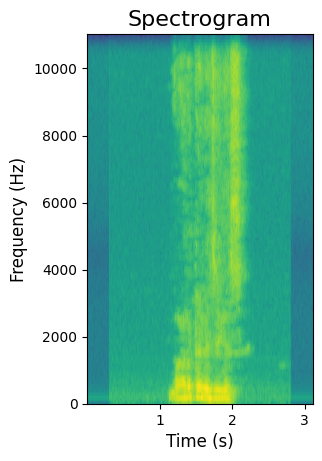

In [115]:
audioFile = '/kaggle/input/bangla/bangla/Sad/03-01-02-01-01-01-01.wav'

waveform, sampleRate = librosa.load(audioFile)

plt.subplot(1, 2, 2)
plt.specgram(waveform, Fs = sampleRate)
plt.title('Spectrogram', fontsize = 16)
plt.xlabel('Time (s)', fontsize = 12)
plt.ylabel('Frequency (Hz)', fontsize = 12)

plt.show()

In [116]:
emotion_map = {
    'angry': 'Anger',
    'surprised': 'Surprise',
    'happy': 'Happiness',
    'sad': 'Sadness',
    'natural': 'Neutral',
    'neutral': 'Neutral'
}

data = []

for emotion_folder in tqdm(os.listdir(bangla), desc='Processing folders'):
    emotion_path = os.path.join(bangla, emotion_folder)

    if os.path.isdir(emotion_path):  # Ensure it's a directory
        for file in os.listdir(emotion_path):
            filePath = os.path.join(emotion_path, file)

            if file.endswith('.wav'):
                features = extractFeatures(filePath)

                if features is not None:
                    emotion = emotion_map.get(emotion_folder.lower(), 'unknown')  
                    data.append([features, emotion])

Processing folders: 100%|██████████| 5/5 [00:34<00:00,  6.81s/it]


In [117]:
bangla_df = pd.DataFrame(data, columns=['Features', 'Emotions'])

print(bangla_df.head())
print("______________________________________________")
print(bangla_df.tail())
print("_________________________________________")
print(bangla_df.Emotions.value_counts())

                                            Features Emotions
0  [[0.5586802, -0.25286207, -0.3017487, -0.92410...    Anger
1  [[0.7911289, -0.31652662, 0.01168099, -0.90390...    Anger
2  [[-0.28401706, -0.10793677, 0.09138116, -0.458...    Anger
3  [[0.23719646, -0.24559703, 0.2603096, -0.37019...    Anger
4  [[-0.04999715, 0.059994772, 0.043727458, 0.146...    Anger
______________________________________________
                                               Features Emotions
1075  [[0.43323138, -0.22457236, 0.05776985, -0.6698...  Neutral
1076  [[0.07960844, -0.2430841, 0.25166893, -0.13401...  Neutral
1077  [[0.21192543, -0.3045121, 0.12215559, -0.35883...  Neutral
1078  [[-0.19561282, 0.0058958083, -0.02456665, -0.3...  Neutral
1079  [[-0.20942423, -0.019047692, -0.08269417, 0.26...  Neutral
_________________________________________
Emotions
Anger        216
Sadness      216
Surprise     216
Happiness    216
Neutral      216
Name: count, dtype: int64


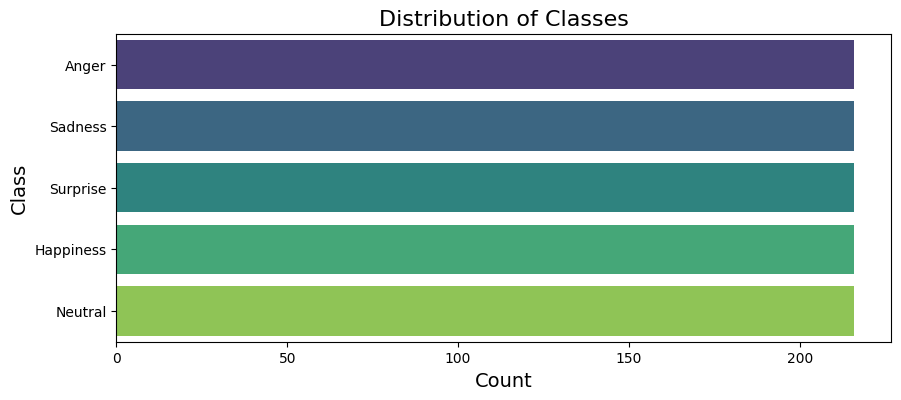

In [118]:
data = pd.DataFrame(data, columns=['Features', 'Class'])
data.head()

# Plotting count distribution of classes
plt.figure(figsize=(10, 4))
sns.countplot(y=data['Class'], palette='viridis')
plt.title('Distribution of Classes', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Class', fontsize=14)
plt.show()

> 5. KANANDA 

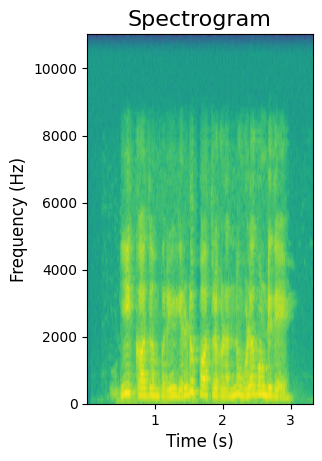

In [120]:
audioFile = '/kaggle/input/kannada/kannada/kannada/01-01-02.wav'

waveform, sampleRate = librosa.load(audioFile)

plt.subplot(1, 2, 2)
plt.specgram(waveform, Fs = sampleRate)
plt.title('Spectrogram', fontsize = 16)
plt.xlabel('Time (s)', fontsize = 12)
plt.ylabel('Frequency (Hz)', fontsize = 12)

plt.show()

In [121]:
data = []

emotion_mapping = {
    '1': 'Anger',
    '2': 'Sadness',
    '3': 'Surprise',
    '4': 'Happiness',
    '5': 'Fear',
    '6': 'Neutral'
}
for file in tqdm(os.listdir(kannada), desc='Processing files'):
    filePath = os.path.join(kannada, file)

    if file.endswith('.wav'):
        # Extract features from the audio file
        features = extractFeatures(filePath)

        if features is not None:
            emotion_code = file[4]  
            emotion = emotion_mapping.get(emotion_code, 'unknown')  
            data.append([features, emotion])

Processing files: 100%|██████████| 468/468 [00:16<00:00, 29.18it/s]


In [122]:
kannada_df = pd.DataFrame(data, columns=['Features', 'Emotions'])

print(kannada_df.head())
print("______________________________________________")
print(kannada_df.tail())
print("_________________________________________")
print(kannada_df.Emotions.value_counts())

                                            Features   Emotions
0  [[-0.07228947, -0.15022045, -0.14010519, -0.00...    Neutral
1  [[-0.21047863, 0.30308443, 0.21780367, -0.7336...    Neutral
2  [[-0.27234337, 0.32667843, 0.03385195, -0.6482...  Happiness
3  [[-0.03487882, 0.105618045, 0.41841578, -0.123...      Anger
4  [[0.04202673, -0.12224305, 0.032100916, -0.268...       Fear
______________________________________________
                                              Features   Emotions
463  [[0.22941774, -0.20018849, 0.17775428, -0.4764...    Neutral
464  [[0.67325425, -0.08639377, 0.1983295, -0.61435...    Neutral
465  [[0.38873935, -0.41338834, 0.29005265, -0.7184...       Fear
466  [[0.0548867, -0.2779697, 0.5475487, -0.6704227...   Surprise
467  [[0.087059736, 0.0077446997, 0.2465032, -0.313...  Happiness
_________________________________________
Emotions
Neutral      78
Happiness    78
Anger        78
Fear         78
Sadness      78
Surprise     78
Name: count, dtype: int64


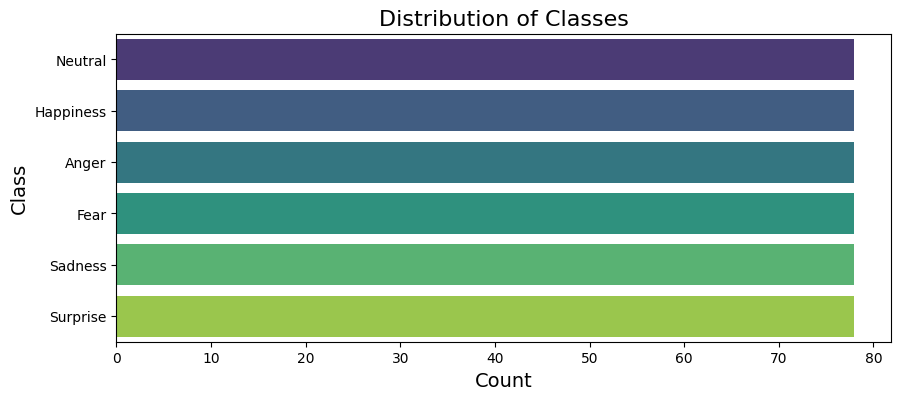

In [123]:
data = pd.DataFrame(data, columns=['Features', 'Emotions'])
data.head()

plt.figure(figsize=(10, 4))
sns.countplot(y=data['Emotions'], palette='viridis')
plt.title('Distribution of Classes', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Class', fontsize=14)
plt.show()

COMBINE

In [124]:
combo = pd.concat([ravdess_df, emodb_df, tess_df, bangla_df, kannada_df], axis = 0)
combo.to_csv("combo6.csv",index=False)
combo.head()

,Features,Emotions
0,"[[0.29071337, -0.23754919, 0.049498662, -0.274...",Surprise
1,"[[0.7098691, -0.29326525, -0.25508785, -0.8122...",Neutral
2,"[[0.770166, -0.20492303, -0.13505906, -0.61996...",Disgust
3,"[[-0.22096476, -0.24673536, 0.15931827, -0.015...",Disgust
4,"[[0.9586816, -0.35651866, -0.01613319, -0.5709...",Neutral


In [125]:
print(combo.Emotions.value_counts())

Emotions
Anger           1013
Happiness        957
Sadness          948
Surprise         886
Neutral          869
Fear             739
Disgust          638
Boredom/Calm     273
Name: count, dtype: int64


In [126]:
combo = combo[combo['Emotions'] != 'Boredom/Calm']

print(combo['Emotions'].value_counts())

Emotions
Anger        1013
Happiness     957
Sadness       948
Surprise      886
Neutral       869
Fear          739
Disgust       638
Name: count, dtype: int64


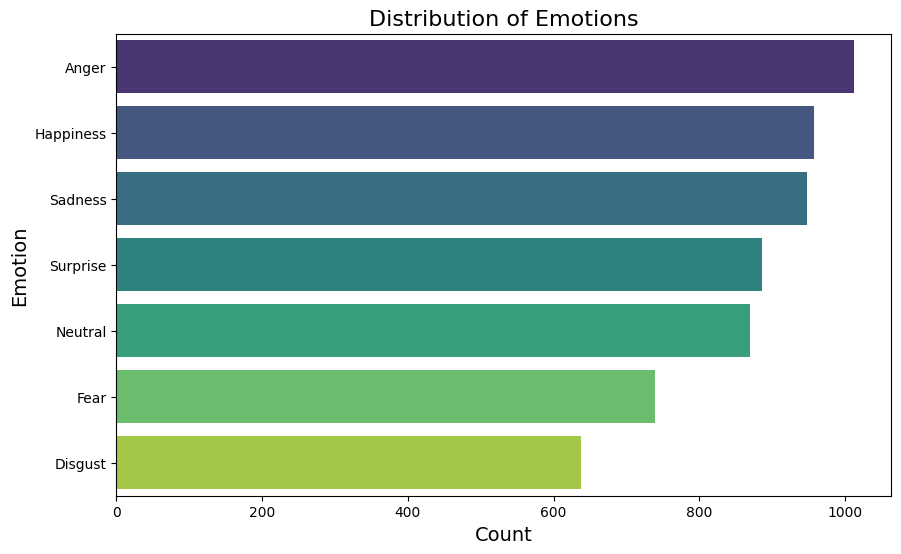

In [127]:
plt.figure(figsize=(10, 6))
sns.countplot(y=combo['Emotions'], palette='viridis', order=combo['Emotions'].value_counts().index)
plt.title('Distribution of Emotions', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Emotion', fontsize=14)
plt.show()

PADDING

In [128]:
x = combo['Features'].tolist()

feature_shapes = [features.shape for features in x]
print("Feature shapes:", feature_shapes)  # Print shapes of features to debug

Feature shapes: [(3, 128), (3, 128), (3, 128), (4, 128), (3, 128), (3, 128), (2, 128), (4, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (4, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (4, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (3, 128), (4, 128), (3, 128), (2, 128), (4, 128), (2, 128), (3, 128), (3, 128), (3, 128), (4, 128), (3, 128), (3, 128), (2, 128), (4, 128), (3, 128), (3, 128), (3, 128), (2, 128), (4, 128), (3, 128), (3, 128), (3, 128), (5, 128), (5, 128), (4, 128), (5, 128), (5, 128), (5, 128), (5, 128), (4, 128), (5, 128), (4, 128), (4, 128), (5, 128), (5, 128), (4, 128), (5, 128), (5, 128), (4, 128), (4, 128), (2, 128), (2, 128), (5, 128), (5, 128), (6, 128), (5, 128), (5, 128), (5, 128), (4, 128), (5, 128), (5, 128), (5, 128), (4, 128), (5, 128), (4, 128), (4, 128), (4, 128), (4, 128), (5, 128), (5, 128), (5, 128), (5, 128), (4, 128), (5, 128), (4, 128), (4, 128), (6, 128), (5,

In [129]:
import numpy as np

target_shape = (5, 128)
padded_features = []

for features in combo['Features']:
    if features is not None:
        current_shape = features.shape

        padded_feature = np.zeros(target_shape)

        if current_shape[0] < target_shape[0]:
            padded_feature[:current_shape[0], :current_shape[1]] = features
        else:
            padded_feature = features[:target_shape[0], :target_shape[1]]

        padded_features.append(padded_feature)

x = np.array(padded_features)
y = combo['Emotions'].values


In [130]:
print("Shape of x:", x.shape)
print("Length of y:", len(y))

Shape of x: (6050, 5, 128)
Length of y: 6050


In [131]:
print("Shape of x:", x.shape)
print("Length of y:", len(y))

Shape of x: (6050, 5, 128)
Length of y: 6050


In [132]:
x = np.array(padded_features)

y = combo['Emotions'].values

first_feature_shape = x[0].shape
expected_height = first_feature_shape[0]
expected_width = first_feature_shape[1]

x = x.reshape((-1, expected_height, expected_width, 1))

print(f"Reshaped x shape: {x.shape}")
print(f"Length of y: {len(y)}")


Reshaped x shape: (6050, 5, 128, 1)
Length of y: 6050


ENCODING

In [133]:
encoder = LabelEncoder()
y = encoder.fit_transform(combo['Emotions'])
y = to_categorical(y)

 # 3. ***CNN MODEL***

In [134]:
import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = tf.keras.Sequential([
    L.Input(shape=(1620,)), 

    L.Reshape((12, 135)),  
    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),

    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    L.Dropout(0.2),

    L.Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),

    L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    L.Dropout(0.3),

    L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=3, strides=2, padding='same'),
    L.Dropout(0.4),

    L.Flatten(),
    L.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    L.BatchNormalization(),
    L.Dropout(0.5),

    L.Dense(7, activation='softmax')  
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 12, 135)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 12, 512)        │       346,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 512)         │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 3, 256)         │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1, 128)         │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,650,759 (10.11 MB)

 Trainable params: 2,646,919 (10.10 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [135]:
import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [136]:
print(x_train.shape)

(14520, 1620)


In [137]:
print("Train data shape:", x_train.shape)
print("Validation data shape:", x_test.shape)

Train data shape: (14520, 1620)
Validation data shape: (3630, 1620)


In [138]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [139]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")


x_train shape: (14520, 1620)
y_train shape: (14520, 7)
x_test shape: (3630, 1620)
y_test shape: (3630, 7)


In [140]:
from keras.callbacks import ModelCheckpoint
from keras.callbacks import LearningRateScheduler

def scheduler(epoch, lr):
    if epoch >40:  
        return float(lr * tf.math.exp(-0.1))
    return lr

lr_scheduler_callback = LearningRateScheduler(scheduler)
lr_scheduler_plateau = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

checkpoint_filepath = 'best_model8.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1)

In [142]:
history = model.fit(x_train, y_train, epochs=120, batch_size=64, validation_data=(x_test, y_test), callbacks=[lr_scheduler_callback, lr_scheduler_plateau, model_checkpoint_callback])

Epoch 1/120
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2011 - loss: 5.5899

I0000 00:00:1732124826.307625     136 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_14', 4 bytes spill stores, 12 bytes spill loads




Epoch 1: val_accuracy improved from -inf to 0.32865, saving model to best_model8.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.2013 - loss: 5.5878 - val_accuracy: 0.3287 - val_loss: 4.0671 - learning_rate: 0.0010
Epoch 2/120
221/227 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2957 - loss: 4.1037
Epoch 2: val_accuracy improved from 0.32865 to 0.40909, saving model to best_model8.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2965 - loss: 4.0956 - val_accuracy: 0.4091 - val_loss: 3.2210 - learning_rate: 0.0010
Epoch 3/120
221/227 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3837 - loss: 3.1732
Epoch 3: val_accuracy improved from 0.40909 to 0.45758, saving model to best_model8.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3841 - loss: 3.1681 - val_accuracy: 0.4576 - val_loss: 2.6320 - learning_rate: 0.0010
Epoch 4/120
225/227 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4281 - loss: 2.6153
Epoch 4: val_accuracy improved from 0.45758 to

In [143]:
historyDf = pd.DataFrame(history.history)

# 4. ***METRICS***

<Axes: >

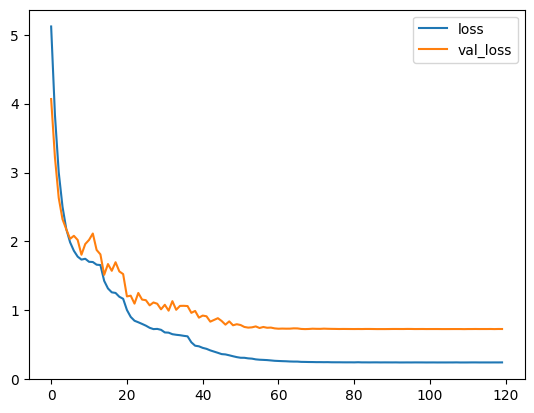

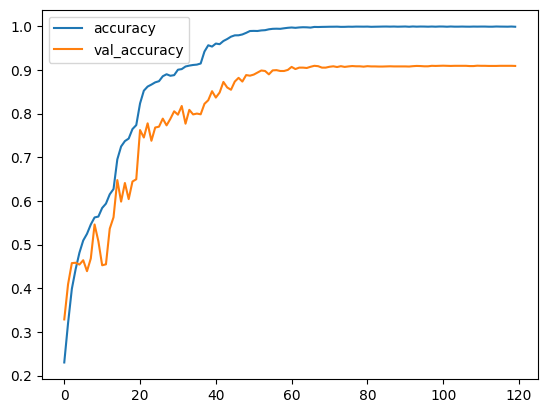

In [144]:
historyDf.loc[:, ['loss', 'val_loss']].plot()
historyDf.loc[:, ['accuracy', 'val_accuracy']].plot()

In [145]:
score = model.evaluate(x_test, y_test)[1] * 100
print(f'Validation accuracy of model: {score:.2f}%')

114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8991 - loss: 0.7755
Validation accuracy of model: 90.91%


In [146]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [147]:
class_report = classification_report(y_test_classes, y_pred_classes)
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       634
           1       0.96      0.92      0.94       376
           2       0.91      0.91      0.91       444
           3       0.87      0.88      0.87       582
           4       0.89      0.93      0.91       544
           5       0.93      0.92      0.92       564
           6       0.88      0.89      0.89       486

    accuracy                           0.91      3630
   macro avg       0.91      0.91      0.91      3630
weighted avg       0.91      0.91      0.91      3630



114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


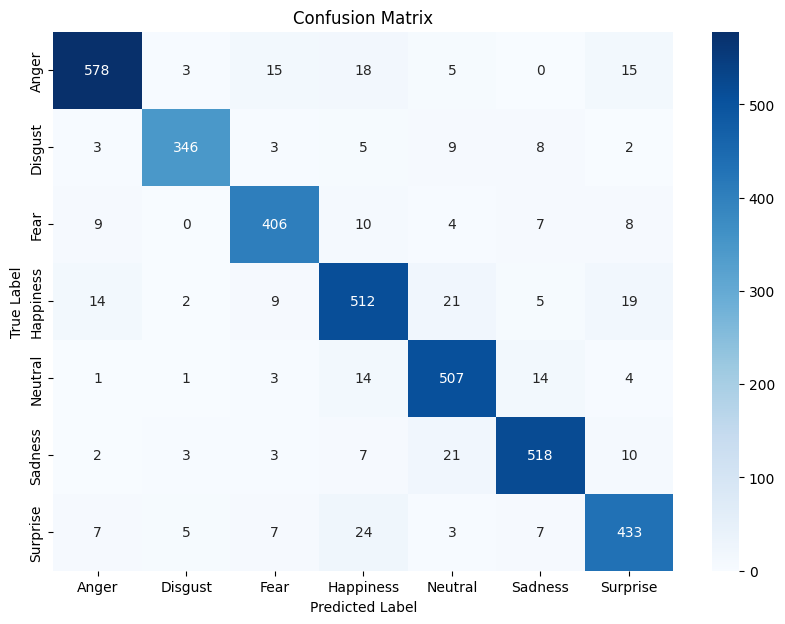

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

class_names = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

def plot_confusion_matrix(model, x_test, y_test, class_names):
    y_pred = model.predict(x_test)
    if y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
    y_test_labels = np.argmax(y_test, axis=1) if y_test.shape[1] > 1 else y_test
    
    cm2 = confusion_matrix(y_test_labels, y_pred)
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    return cm2
cm2 = plot_confusion_matrix(model, x_test, y_test, class_names)

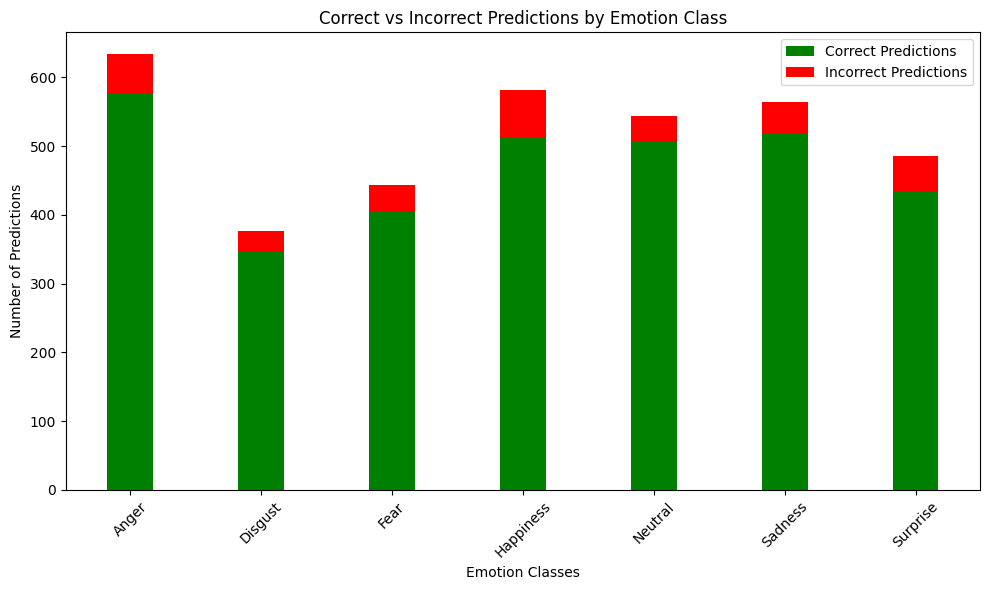

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class_names = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

total_files = np.sum(cm2, axis=1)

correct_predictions = np.diag(cm2)

incorrect_predictions = total_files - correct_predictions

index = np.arange(len(class_names))
bar_width = 0.35  

plt.figure(figsize=(10, 6))
plt.bar(index, correct_predictions, bar_width, label='Correct Predictions', color='green')
plt.bar(index, incorrect_predictions, bar_width, bottom=correct_predictions, label='Incorrect Predictions', color='red')

plt.xlabel('Emotion Classes')
plt.ylabel('Number of Predictions')
plt.title('Correct vs Incorrect Predictions by Emotion Class')
plt.xticks(index, class_names, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# 5. ***BASELINE MODEL***

Baseline accuracy (majority class): 17.47%
Model accuracy: 90.91%
Your model is performing better than the baseline model.


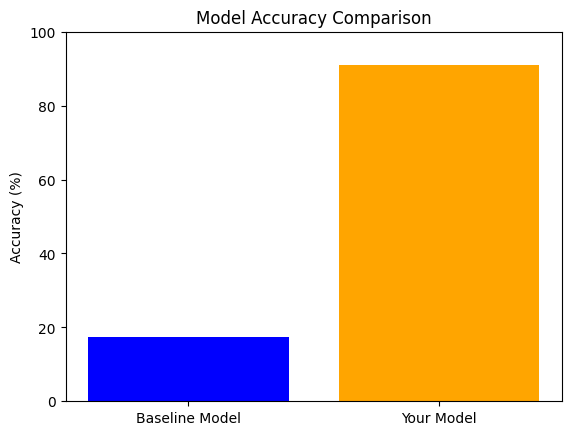

In [150]:
from sklearn.metrics import accuracy_score
majority_class = y_train.argmax(axis=1) 
majority_class_value = np.bincount(majority_class).argmax()  

baseline_predictions = np.full(y_test.shape[0], majority_class_value)  
baseline_accuracy = accuracy_score(y_test.argmax(axis=1), baseline_predictions)
print(f'Baseline accuracy (majority class): {baseline_accuracy * 100:.2f}%')


model_accuracy = score  # Your model's accuracy from evaluation
print(f'Model accuracy: {model_accuracy:.2f}%')

if model_accuracy > baseline_accuracy * 100:
    print("Your model is performing better than the baseline model.")
else:
    print("Your model is not performing better than the baseline model.")


accuracies = [baseline_accuracy * 100, model_accuracy]
labels = ['Baseline Model', 'Your Model']

plt.bar(labels, accuracies, color=['blue', 'orange'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
plt.show()

# ***STACKING***

In [151]:
print(x_train.shape)
import numpy as np

(14520, 1620)


In [152]:
timesteps_target = 1620
num_features = 1

lstm_train_pred = model01.predict(X_train)

num_samples = 4466
timesteps = 1620

lstm_test_pred = model01.predict(X_test)

454/454 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step


In [153]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

cnn_train_pred = model.predict(x_train)  # CNN
cnn_test_pred = model.predict(x_test)  # CNN

454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [154]:
print(f'CNN Train Prediction Shape: {cnn_train_pred.shape}')
print(f'LSTM Train Prediction Shape: {lstm_train_pred.shape}')
print(f'CNN Test Prediction Shape: {cnn_test_pred.shape}')
print(f'LSTM Test Prediction Shape: {lstm_test_pred.shape}')

CNN Train Prediction Shape: (14520, 7)
LSTM Train Prediction Shape: (14520, 7)
CNN Test Prediction Shape: (3630, 7)
LSTM Test Prediction Shape: (3630, 7)


In [155]:
stacked_train = np.hstack((cnn_train_pred, lstm_train_pred))
stacked_test = np.hstack((cnn_test_pred, lstm_test_pred))

In [156]:
meta_clf = LogisticRegression(max_iter=1000)
meta_clf.fit(stacked_train, np.argmax(y_train, axis=1))

stacked_pred = meta_clf.predict(stacked_test)

In [157]:
final_accuracy = accuracy_score(np.argmax(y_test, axis=1), stacked_pred)
print(f"Stacked Model Accuracy: {final_accuracy * 100:.2f}%")

Stacked Model Accuracy: 91.87%


In [158]:
class_report = classification_report(y_test_classes, y_pred_classes)
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       634
           1       0.96      0.92      0.94       376
           2       0.91      0.91      0.91       444
           3       0.87      0.88      0.87       582
           4       0.89      0.93      0.91       544
           5       0.93      0.92      0.92       564
           6       0.88      0.89      0.89       486

    accuracy                           0.91      3630
   macro avg       0.91      0.91      0.91      3630
weighted avg       0.91      0.91      0.91      3630



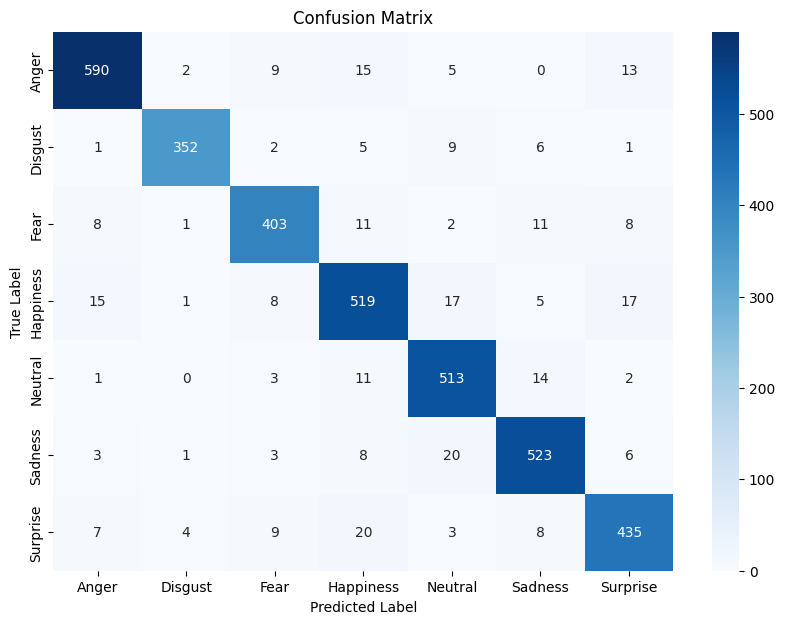

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

class_names = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

def plot_confusion_matrix(meta_clf, stacked_test, y_test_labels, class_names):
    y_pred = meta_clf.predict(stacked_test)
    
    if y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)
    y_test_labels = np.argmax(y_test_labels, axis=1) if y_test_labels.ndim > 1 else y_test_labels
    
    cm3 = confusion_matrix(y_test_labels, y_pred)
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    return cm3

cm3 = plot_confusion_matrix(meta_clf, stacked_test, y_test, class_names)

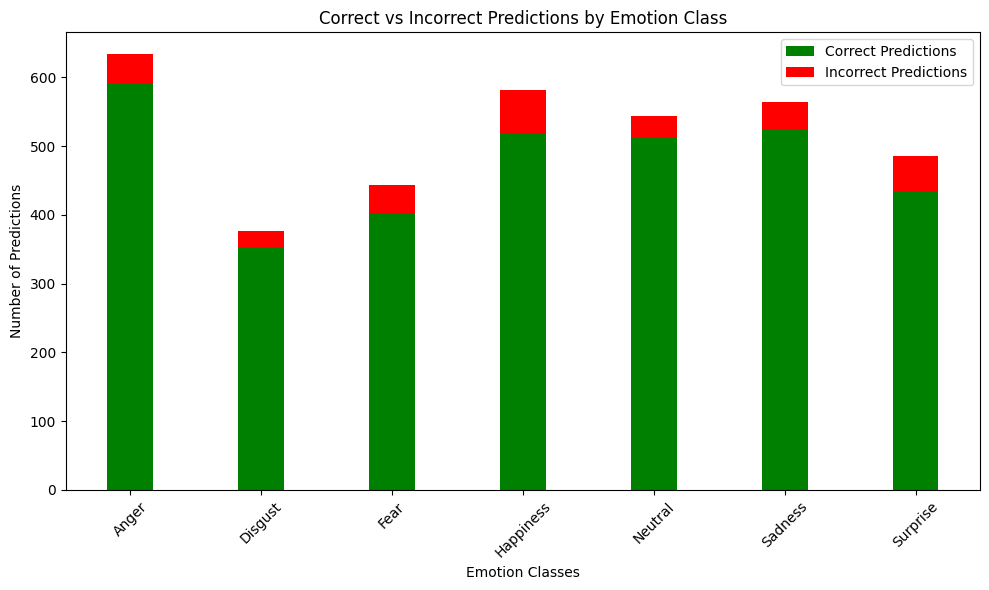

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class_names = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

total_files = np.sum(cm3, axis=1)

correct_predictions = np.diag(cm3)

incorrect_predictions = total_files - correct_predictions

index = np.arange(len(class_names)) 
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(index, correct_predictions, bar_width, label='Correct Predictions', color='green')
plt.bar(index, incorrect_predictions, bar_width, bottom=correct_predictions, label='Incorrect Predictions', color='red')

plt.xlabel('Emotion Classes')
plt.ylabel('Number of Predictions')
plt.title('Correct vs Incorrect Predictions by Emotion Class')
plt.xticks(index, class_names, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [161]:
import joblib
joblib.dump(meta_clf, "stack3.pkl")

['stack3.pkl']

# EXTRA GRAPHS

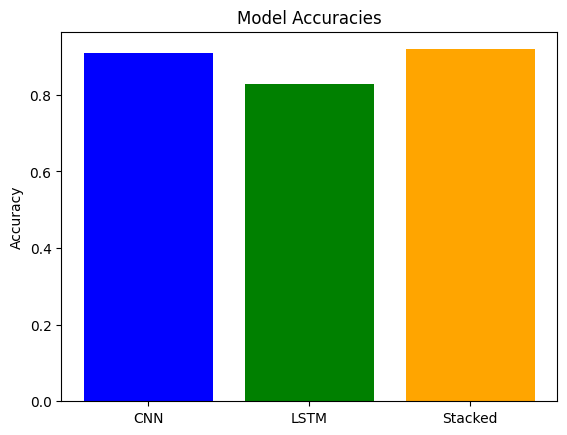

In [162]:
cnn_accuracy = accuracy_score(np.argmax(y_test, axis=1), cnn_test_pred.argmax(axis=1))
lstm_accuracy = accuracy_score(np.argmax(y_test, axis=1), lstm_test_pred.argmax(axis=1))
stacked_accuracy = final_accuracy

import matplotlib.pyplot as plt

models = ['CNN', 'LSTM', 'Stacked']
accuracies = [cnn_accuracy, lstm_accuracy, stacked_accuracy]

plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.title('Model Accuracies')
plt.ylabel('Accuracy')
plt.show()

In [163]:
from sklearn.metrics import classification_report

class_report = classification_report(
    np.argmax(y_test, axis=1), 
    stacked_pred,             
    target_names=['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
)

# Print the report
print("Classification Report for Stacked Logistic Regression Model:")
print(class_report)

Classification Report for Stacked Logistic Regression Model:
              precision    recall  f1-score   support

       Anger       0.94      0.93      0.94       634
     Disgust       0.98      0.94      0.96       376
        Fear       0.92      0.91      0.91       444
   Happiness       0.88      0.89      0.89       582
     Neutral       0.90      0.94      0.92       544
     Sadness       0.92      0.93      0.92       564
    Surprise       0.90      0.90      0.90       486

    accuracy                           0.92      3630
   macro avg       0.92      0.92      0.92      3630
weighted avg       0.92      0.92      0.92      3630



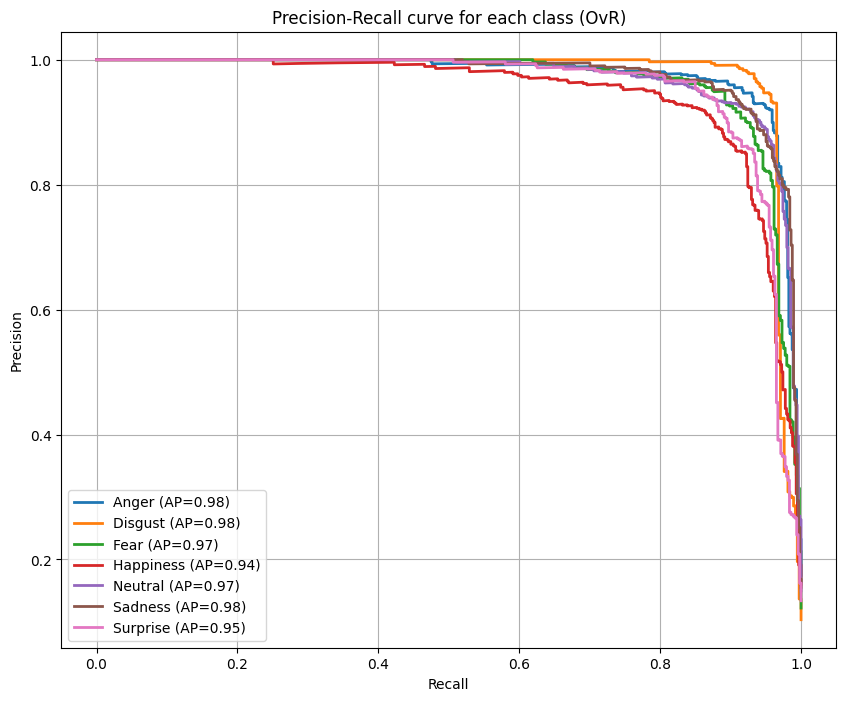

In [167]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
stacked_prob = meta_clf.predict_proba(stacked_test) 

y_test_binarized = label_binarize(np.argmax(y_test, axis=1), classes=np.arange(7))
n_classes = y_test_binarized.shape[1]

class_names = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']

precision = {}
recall = {}
average_precision = {}

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_binarized[:, i], stacked_prob[:, i])
    average_precision[i] = average_precision_score(y_test_binarized[:, i], stacked_prob[:, i])
    
    plt.plot(recall[i], precision[i], lw=2, label=f'{class_names[i]} (AP={average_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve for each class (OvR)')
plt.legend(loc="best")
plt.grid(True)
plt.show()

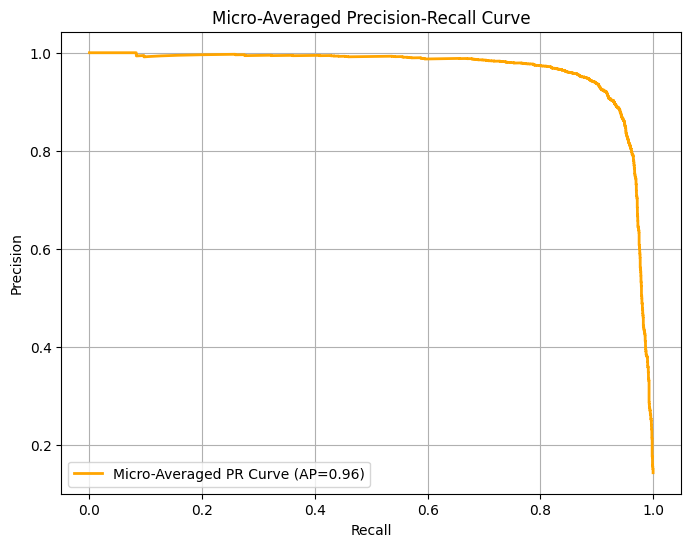

In [168]:
precision_micro, recall_micro, _ = precision_recall_curve(y_test_binarized.ravel(), stacked_prob.ravel())
average_precision_micro = average_precision_score(y_test_binarized, stacked_prob, average='micro')

plt.figure(figsize=(8, 6))
plt.plot(recall_micro, precision_micro, color='orange', lw=2, 
         label=f'Micro-Averaged PR Curve (AP={average_precision_micro:.2f})')

# Global settings for the plot
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-Averaged Precision-Recall Curve')
plt.legend(loc="best")
plt.grid(True)
plt.show()


In [169]:
from sklearn.metrics import log_loss
stacked_prob = meta_clf.predict_proba(stacked_test)  

# Calculate log-loss for test set predictions
log_loss_value = log_loss(y_test, stacked_prob)
print(f"Log-Loss: {log_loss_value:.4f}")

Log-Loss: 0.3433


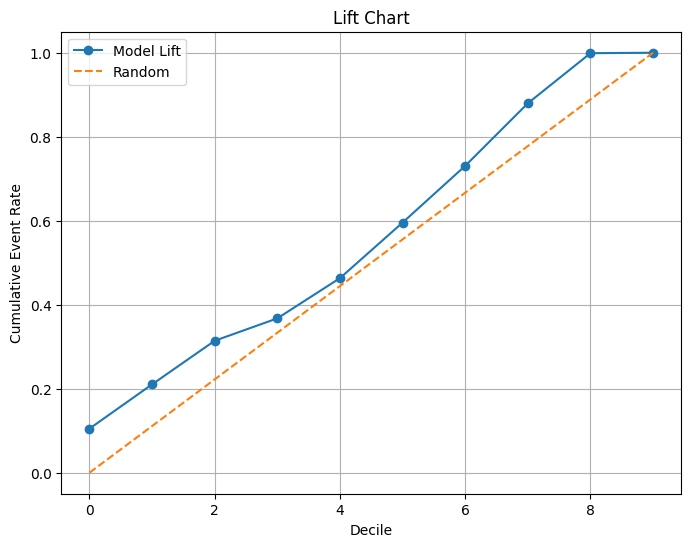

In [170]:
import numpy as np
import pandas as pd
import seaborn as sns

predicted_prob = np.max(stacked_prob, axis=1)  # Maximum probability for each sample
data = pd.DataFrame({
    'actual': np.argmax(y_test, axis=1),
    'probability': predicted_prob
})


data['decile'] = pd.qcut(data['probability'], 10, labels=False)

# Calculate Lift
lift_data = data.groupby('decile').apply(
    lambda x: pd.Series({
        'total': len(x),
        'events': x['actual'].sum(),
        'non_events': len(x) - x['actual'].sum()
    })
).reset_index()

lift_data['event_rate'] = lift_data['events'] / lift_data['total']
lift_data['cumulative_event_rate'] = lift_data['events'].cumsum() / lift_data['events'].sum()
lift_data['random_rate'] = lift_data['decile'] / 9

# Plot Lift Chart
plt.figure(figsize=(8, 6))
plt.plot(lift_data['decile'], lift_data['cumulative_event_rate'], marker='o', label='Model Lift')
plt.plot(lift_data['decile'], lift_data['random_rate'], linestyle='--', label='Random')
plt.xlabel('Decile')
plt.ylabel('Cumulative Event Rate')
plt.title('Lift Chart')
plt.legend()
plt.grid()
plt.show()
